# Data Analysis project
## Spotify songs Dataset

### EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume

### I.Nettoyage et exploration du dataset
#### Importation et nettoyage des données 
Dans ce projet, nous allons analyser un jeu de données contenant plusieurs informations sur des chansons écoutées sur Spotify.  
Pour chaque chanson, nous avons les variables suivantes :
- track_id
- track_name
- track_artist
- track_popularity : une note entre 0 et 100
- track_album_id : l'identifiant de l'album de la musique
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre : genre de la playlist dans laquelle est la musique
- danceability : flottant entre 0 et 1 pour quantifier si la musique est dansable, sur la base de critères tels que le tempo, la stabilité du rythme, la force des battements et la régularité générale.
- energy : flottant entre 0 et 1 représentant une mesure perceptuelle de l'intensité et de l'activité
- key : estimation de la tonalité du morceau, 0=C, 1=C#, 2=D ... -1=aucune tonalité détectée
- loudness :intensité sonore en moyenne d'une musique en décibels (dB)
- mode : modalité d'une musique : majeur = 1, mineur = 0
- speechiness : flottant entre 0 et 1 indiquant la présence de paroles dans une piste >2/3 : presque uniquement des paroles, 1/3< <2/3 : contient à la fois de la musique et de la parole, <1/3 : pistes musicales et non parlantes
- acousticness : flottant entre 0 et 1 décrivant si la chanson est acoustique
- instrumentalness : flottant entre 0 et 1 représentant si la piste est plus vocale : proche de 0 ou instrumentale : proche de 1
- liveness : flottant entre 0 et 1 détectant la présence ou non d'un public. Au dessus de 0.8 la piste est probablement un live d'un concert
- valence : flotteur entre 0 et 1 mesurant la positivité d'une chanson (proche de 1)
- tempo : tempo en battements par minute (BPM)
- duration_ms: durée de la musique en millisecondes

In [137]:
#pip install datasets

In [138]:
#pip install yellowbrick

In [22]:
import pandas as pd
import numpy as np
import prince
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import colors

#from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
# from datasets import load_dataset

In [26]:
song = pd.read_csv("spotify_songs.csv")

In [27]:
song.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


On voit qu'on a beaucoup de duplicatas. En cherchant dans le dataset, on a découvert que ces duplicatas sont enfait dans différentes playlists qui n'ont pas le même genre. On en déduit que l'extraction des données a été faites via les playlists et c'est donc pour cela qu'on a des duplicatas. Nous allons garder qu'une seule occurence de chaque musique. Pour choisir laquelle, nous allons garder une occurence dont le genre (puis le sous-genre) est le mode des différents genres de la musique (différents genres des différentes occurences de la musique). Exemple: Dancing Queen apparait 3 fois, 2 fois avec pop et une fois avec latin, on va garder une occurence de pop.
On en profite également pour stocker dans une nouvelle variable le nombre de playlist où apparait la musique. Cependant, une musique présente dans de nombreuses playlists implique que cette musique doit être plutôt écouté et pour ne pas perdre non plus toutes l'information, on va garder pour chaque musique son nombre d'apparitions dans le dataset.

Ce nettoyage particulier est réalisé notamment pour les analyses factorielles afin de ne pas trop les biaiser avec une musique apparaissant plus que d'autres. Pour certaines méthodes, notamment la NMF, on va utiliser le dataset complet pour obtenir de meilleurs résultats.

In [28]:
# 1. Compter combien de fois chaque track_id apparaît
song['playlist_appearance_count'] = song.groupby('track_id')['track_id'].transform('count')

# 2. Garder le genre le plus fréquent pour chaque track_id
genre_counts = song.groupby(['track_id', 'playlist_genre']).size().reset_index(name='genre_count')
# On récupère le genre le plus fréquent pour chaque track
genre_dominant = genre_counts.loc[genre_counts.groupby('track_id')['genre_count'].idxmax()]

# 3. Merger avec song pour ne garder que les lignes correspondant au genre dominant
song = song.merge(genre_dominant[['track_id', 'playlist_genre']], on=['track_id', 'playlist_genre'])

# 4. Garder le sous-genre le plus fréquent pour chaque track_id
subgenre_counts = song.groupby(['track_id', 'playlist_subgenre']).size().reset_index(name='subgenre_count')
subgenre_dominant = subgenre_counts.loc[subgenre_counts.groupby('track_id')['subgenre_count'].idxmax()]

# 5. Merger avec song pour ne garder que les lignes correspondant au sous-genre dominant
song = song.merge(subgenre_dominant[['track_id', 'playlist_subgenre']], on=['track_id', 'playlist_subgenre'])

# 6. Vérifier s'il reste des doublons de track_id
nb_duplicates = song.duplicated(subset='track_id').sum()
print(nb_duplicates)


0


In [29]:
print(song.iloc[1299])

track_id                       0RQEDIV1tgkz66llhdUqJi
track_name                        Tear Down The Stars
track_artist                        The Years Gone By
track_popularity                                    0
track_album_id                 30WU9cnG33f11JveTQPNgw
track_album_name               Forever Comes Too Soon
track_album_release_date                   2008-09-02
playlist_name                Pop Punk | Post-Hardcore
playlist_id                    1YgWQAs1s77NzieIH4ARKn
playlist_genre                                    pop
playlist_subgenre                       post-teen pop
danceability                                    0.553
energy                                          0.484
key                                                11
loudness                                       -8.655
mode                                                1
speechiness                                    0.0366
acousticness                                    0.651
instrumentalness            

Nous allons maintenant supprimer les variables inutiles à l'analyse comme le `track_id` (un identifiant différent par musique) qui ne sera d'aucune utilité pour notre analyse car l'information est déjà contenue dans la variable `track_name` que nous n'utiliserons que pour labelliser.
De même, on va supprimer `track_album_id`,`playlist_id`.

In [30]:
song.drop('track_id', axis = 1, inplace = True)
song.drop('playlist_id', axis = 1, inplace = True)
song.drop('track_album_id', axis = 1, inplace = True)

On va décomposer la variable de date en jour mois année puis uniquement récupérer le mois et l'année. Si le mois n'est pas présent, il est mit par défaut à 1, on ne va pas s'intéresser trop à cette variable donc cela ne pose pas de problème

In [31]:
from datetime import datetime
#print(song['track_album_release_date'])
years = []
months = []
print(song['track_album_release_date'][1299])
#print(song.size)
for i in range(song.shape[0]):
    #print(song['track_album_release_date'][i])
    #print(i)
    if((len(song['track_album_release_date'][i]))==4):
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y').year)
        months.append(1)
    elif((len(song['track_album_release_date'][i]))==7):
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m').year)
        months.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m').month)
    else:
        years.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m-%d').year)
        months.append(datetime.strptime(song['track_album_release_date'][i], '%Y-%m-%d').month)
song['track_album_release_year'] = pd.Series(years)
song['track_album_release_month'] = pd.Series(months)
song.drop('track_album_release_date', axis = 1, inplace = True)

2008-09-02


On va également ajouter une variable représentant la décennie en utilisant l'année (=>moins de modalités).

In [32]:
# Créer une nouvelle colonne period initialisée à NaN
song['period'] = np.nan

# Appliquer les conditions
song.loc[song['track_album_release_year'] > 2010, 'period'] = '2010s'
song.loc[(song['track_album_release_year'] > 2000) & (song['track_album_release_year'] <= 2010), 'period'] = '2000s'
song.loc[(song['track_album_release_year'] > 1990) & (song['track_album_release_year'] <= 2000), 'period'] = '1990s'
song.loc[(song['track_album_release_year'] > 1980) & (song['track_album_release_year'] <= 1990), 'period'] = '1980s'
song.loc[(song['track_album_release_year'] > 1970) & (song['track_album_release_year'] <= 1980), 'period'] = '1970s'
song.loc[(song['track_album_release_year'] > 1960) & (song['track_album_release_year'] <= 1970), 'period'] = '1960s'
song.loc[song['track_album_release_year'] <= 1960, 'period'] = '1950s'

# Convertir month, year et period en variables catégorielles
song['period'] = song['period'].astype('category')

C:\Users\sliss\AppData\Local\Temp\ipykernel_19612\456570573.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2010s' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  song.loc[song['track_album_release_year'] > 2010, 'period'] = '2010s'


On modifie les variables qualitatives en facteurs. On en utilisera certaines pour les analyses, d'autres ne seront utilisés que pour labelliser.

On va également modifier la variable de durée en la passant en secondes au lieu de millisecondes pour avoir des valeurs plus parlantes.

In [33]:
song['track_artist'] = song['track_artist'].astype('category')
song['track_album_name'] = song['track_album_name'].astype('category')
song['playlist_name'] = song['playlist_name'].astype('category')
song['playlist_genre'] = song['playlist_genre'].astype('category')
song['playlist_subgenre'] = song['playlist_subgenre'].astype('category')
song['mode'] = song['mode'].astype('category')
song['track_album_release_year'] = song['track_album_release_year'].astype('category')
song['track_album_release_month'] = song['track_album_release_month'].astype('category')
song['key'] = song['key'].astype('category')
song['duration_s']=song['duration_ms']/1000
song.drop('duration_ms',axis =1,inplace=True)

In [34]:
print('Columns containing missing values are : ', list(song.columns[song.isnull().sum()!=0]))

Columns containing missing values are :  ['track_name', 'track_artist', 'track_album_name']


In [35]:
print("Track artist - Rate of missing values: {:.2f}%".format(song['track_artist'].isnull().sum()/song.shape[0]*100))

Track artist - Rate of missing values: 0.01%


In [36]:
print("Track album name - Rate of missing values: {:.2f}%".format(song['track_album_name'].isnull().sum()/song.shape[0]*100))

Track album name - Rate of missing values: 0.01%


Comme les NA pour le mois on été géré en les remplacant par une valeur par défaut, on a que quelques NA pour les variables `track_artist` et `track_album_name`. On va les retirer pour éviter des problèmes d'éxécution lors des différentes analyses. On ne perd que très peu d'information (4 valeurs sur tous les datasets).

In [37]:
nb_mv_key = 0
for i in range(song.shape[0]):
    if(song['key'][i] == -1):
        nb_mv_key += 1
print("Key - Number of missing values : {:.2f}".format(nb_mv_key))

Key - Number of missing values : 0.00


Il n'y a aucune valeur manquante pour la clé, contrairement à ce qu'on aurait pu supposer avec le descriptif du jeu de données. Cela fait un problème de moins à régler.

On va supprimer les musiques qui durent moins de 30 secondes car elles sont trop courtes pour qu'on puisse vraiment les juger.

In [38]:
song = song[song['duration_s'] >= 30]

#### Exploration des données

In [39]:
song.describe()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_appearance_count,duration_s
count,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000,28354.000000
mean,39.332546,0.653400,0.698400,-6.816957,0.107954,0.177154,0.091121,0.190940,0.510388,120.961685,1.157897,226.590768
std,23.700910,0.145736,0.183495,3.034176,0.102556,0.222758,0.232556,0.155837,0.234312,26.945128,0.543852,61.055081
min,0.000000,0.077100,0.000175,-46.448000,0.022400,0.000001,0.000000,0.009360,0.000010,35.477000,1.000000,31.429000
25%,21.000000,0.561000,0.579000,-8.309000,0.041000,0.014400,0.000000,0.092600,0.329000,99.972000,1.000000,187.745500
50%,42.000000,0.670000,0.722000,-6.260500,0.062600,0.079700,0.000021,0.127000,0.512000,121.993500,1.000000,216.933000
75%,58.000000,0.760000,0.843000,-4.709000,0.133000,0.260000,0.006568,0.249000,0.695000,133.999000,1.000000,254.975750
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,10.000000,517.810000


(Faire un subplot et analyser)

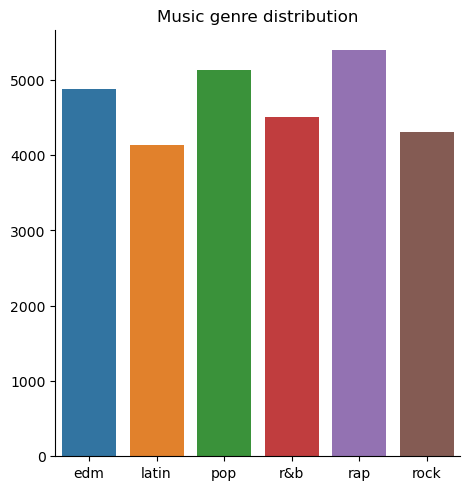

In [156]:
# genre distribution
fig = sns.catplot(data=song, x='playlist_genre', kind='count', hue='playlist_genre')

plt.xlabel('')
plt.ylabel('')
plt.title('Music genre distribution')
plt.show()


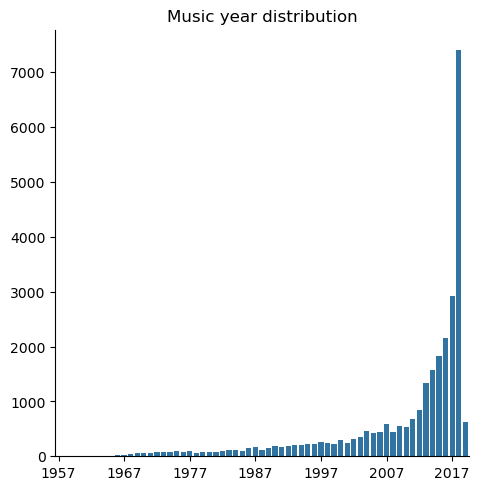

In [157]:
# year of release distribution
fig = sns.catplot(data=song, x='track_album_release_year', kind='count')

plt.xlabel('')
plt.ylabel('')
plt.title('Music year distribution')

xticks = plt.xticks()[0]
plt.xticks(ticks=xticks[::10], labels=[int(t)+min(song['track_album_release_year']) for t in xticks[::10]])
plt.show()

Pour la partie analyse uni- et bidimensionnelle, voir le notebook R.

#### Correlation Plot

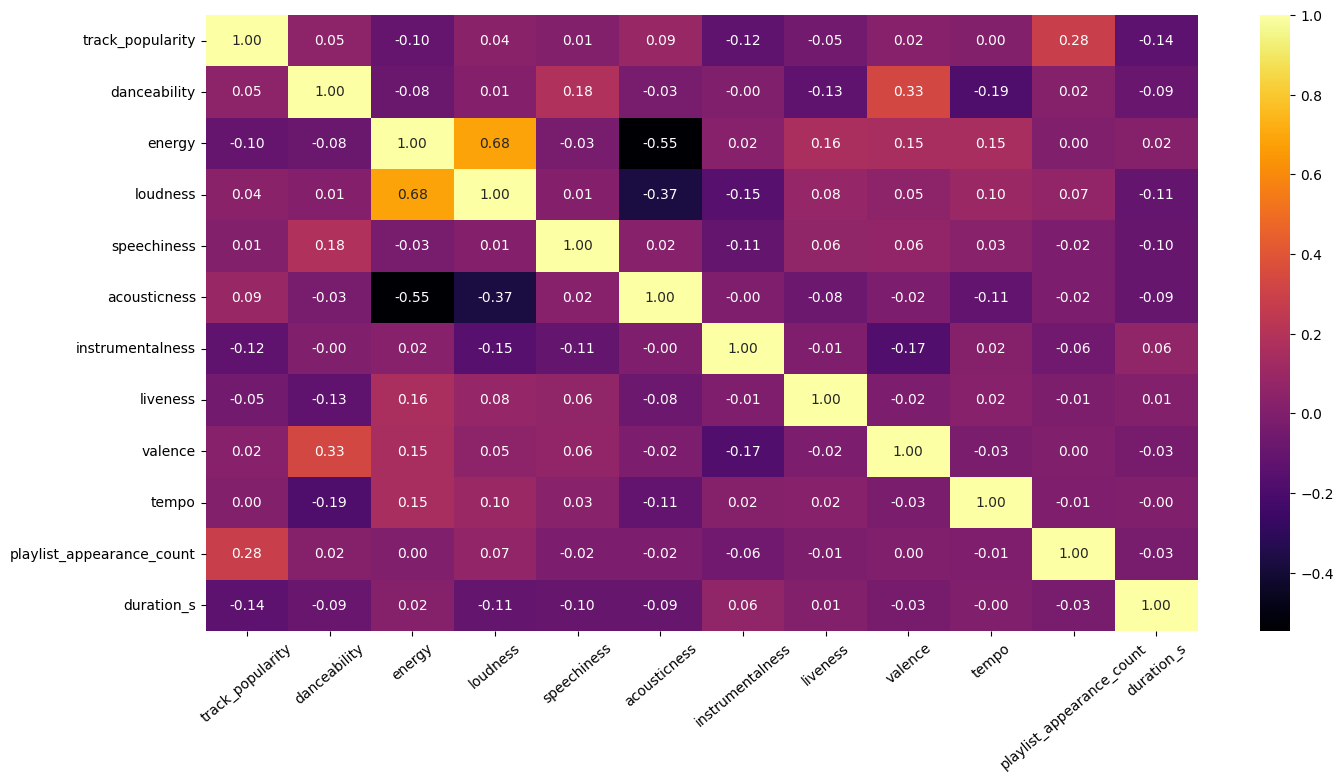

In [40]:
plt.figure(figsize=(16,8))
# correlation between columns
sns.heatmap(song.corr(numeric_only=True), annot=True, fmt='.2f', cmap='inferno')
plt.xticks(rotation=40)

plt.show()

L'énergie et l'intensité sonore sont fortement corrélées positivement.
L'énergie et l'acoustique sont négativement corrélées. L'intensité sonore et l'acoustique sont légèrement corrélées négativement. C'est compréhensible car lorsqu'une chanson devient plus forte, il devient souvent plus difficile de distinguer les différents instruments et sons.
L'aptitude à la danse et la valence sont légèrement corrélées positivement. Ainsi, une chanson sur laquelle il est plus facile de danser est plus susceptible d'inspirer un sentiment positif à ses auditeurs.
On observe également que la popularité et le nombre d'apparition dans les playlists sont moyennement positivement corrélés. On en déduit que d'apparaitre dans plusieurs playlists rend populaire mais la réciproque est fausse, une musique populaire n'est pas forcément dans plusieurs playlists.

On espère que ces corrélations vont nous permettre de réduire la dimension de notre jeu de données.

## ACP

In [41]:
song_quanti = song.select_dtypes(include=['float64', 'int64'])

In [42]:
song_quanti.head()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_appearance_count,duration_s
0,60,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,1,169.093
1,69,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,1,189.052
2,62,0.449,0.856,-4.788,0.0623,0.1870,0.000000,0.1760,0.152,112.648,1,187.675
3,58,0.679,0.923,-6.500,0.1810,0.1460,0.000005,0.1240,0.752,121.984,1,207.894
4,67,0.744,0.726,-4.675,0.0463,0.0399,0.000000,0.3740,0.687,121.985,1,192.507


In [43]:
#classe pour standardisation
from sklearn.preprocessing import StandardScaler
#instanciation
sc = StandardScaler()
#transformation – centrage-réduction
song_quanti_sc = sc.fit_transform(song_quanti)
#print(song_quanti_sc)

We choose to standardize the dataset as duration and tempo have much higher values compared to energy, acousticness etc.

In [44]:
pca = PCA(n_components=11)
pca.fit(song_quanti_sc)

PCA(n_components=11)

In [45]:
var_exp_ratio = np.cumsum(pca.explained_variance_ratio_)

In [46]:
var_exp_ratio

array([0.18133664, 0.31502266, 0.42532588, 0.51815744, 0.60080257,
       0.68147911, 0.75892702, 0.82978706, 0.88639824, 0.93693563,
       0.98162559])

We chose to keep 7 dimensions as we can already explain more than 80% of the variance with them. The PCA did not allow us to drastically reduce the number of dimensions, showing us that the variables do not give the same kind of information overall.

In [47]:
pca = PCA(n_components=7)
projected = pca.fit_transform(song_quanti_sc)

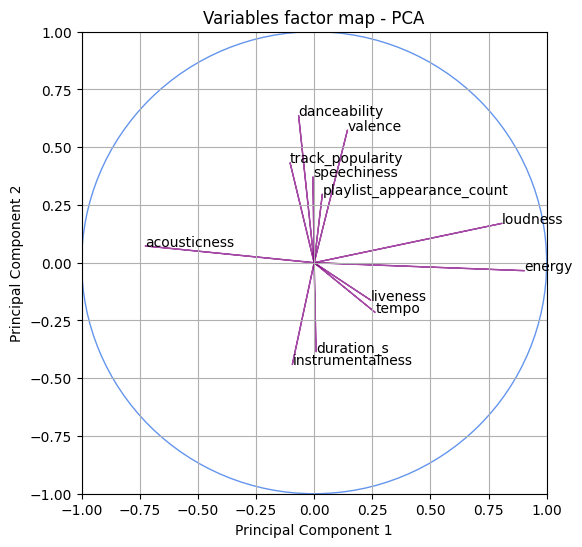

In [48]:
"""
coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])

fig = plt.figure()
for i, j, nom in zip(coord1, coord2, song_quanti.columns):
    plt.text(i, j, nom, fontsize=10)
    plt.arrow(0, 0, i, j, color = 'purple', alpha=0.7, width = 0.0001)

plt.gcf().gca().add_artist(plt.Circle((0, 0), radius = 1, color = 'cornflowerblue', fill = False))

plt.title('Variables factor map - PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True)
plt.show()
"""

coord1 = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2 = pca.components_[1] * np.sqrt(pca.explained_variance_[1])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1, coord2, song_quanti.columns):
    plt.text(i, j, nom, fontsize=10)
    plt.arrow(0, 0, i, j, color = 'purple', alpha=0.7, width = 0.0001)

plt.axis((-1, 1, -1, 1))
plt.gcf().gca().add_artist(plt.Circle((0, 0), radius = 1, color = 'cornflowerblue', fill = False))

plt.title('Variables factor map - PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.grid(True)
plt.show()

We can make the following assumptions about the first two dimensions :
* Dimension 1: energy of the song
* Dimension 2: whether a song is instrumental or not. Instrumental songs tend to be longer, less danceable and popular compared to popular hits.

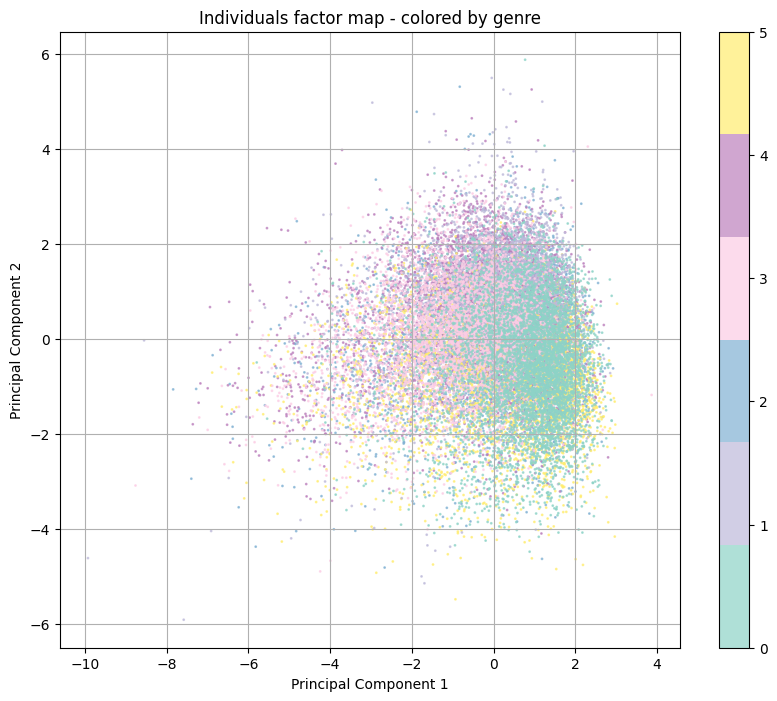

In [50]:
cmap = plt.get_cmap('Set3', 6)
plt.figure(figsize=(10,8))
list_genre = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']
playlist_genre_num = np.zeros(len(song))

for i in range(len(song)):
        playlist_genre_num[i] = list_genre.index(song.iloc[i]['playlist_genre'])

plt.scatter(projected[:, 0], projected[:, 1], s=1, linewidths=1, alpha=0.7, c=playlist_genre_num, cmap=cmap)
plt.title("Individuals factor map - colored by genre")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar()
plt.grid(True)
plt.show()

# KMeans

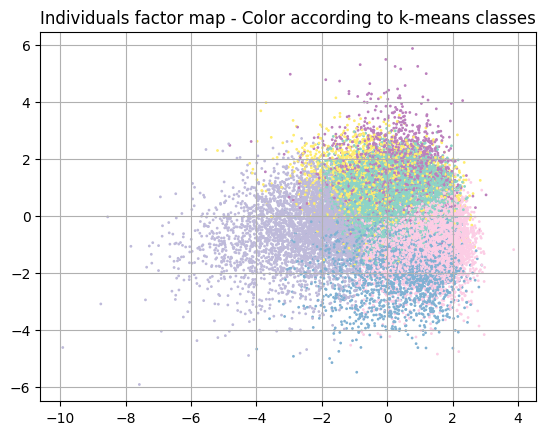

In [51]:
K = 6
kmeans_pca = KMeans(n_clusters=K, init='k-means++', n_init='auto', random_state=0)
clusters_pca = kmeans_pca.fit_predict(projected)

plt.scatter(projected[:,0], projected[:,1], c=clusters_pca, s=1, linewidths=1, cmap=cmap)
plt.title("Individuals factor map - Color according to k-means classes")

plt.grid(True)
plt.show()

# ACH

In [52]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

In [67]:
projected_sampled = projected[::5]

print("Song data - full sample size:", projected.shape)
print("Song data - sub-sample size :", projected_sampled.shape)

Song data - full sample size: (28352, 7)
Song data - sub-sample size : (5671, 7)


We choose to apply the CAH on a sub-sample as it is a lot more time consuming than the K-means method.

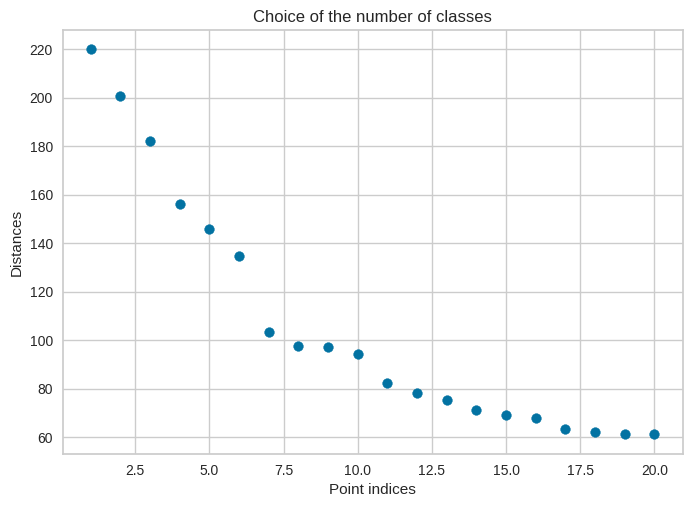

In [68]:
ac = AgglomerativeClustering(linkage="ward", compute_distances=True)
clusters_ac = ac.fit_predict(projected)

distances = ac.distances_

n_sizes = 20
x = np.arange(n_sizes, 0, -1)
y = ac.distances_[-n_sizes:]

plt.scatter(x, y)

plt.xlabel('Point indices')
plt.ylabel('Distances')
plt.title("Choice of the number of classes")
plt.show()

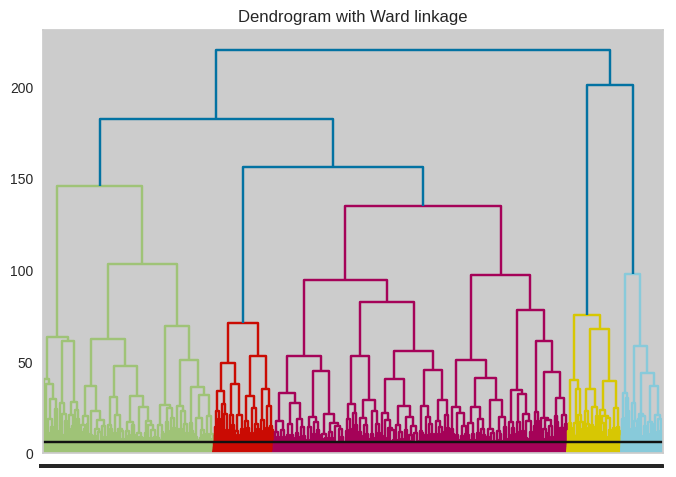

In [71]:
K = 6

ac = AgglomerativeClustering(n_clusters=K, compute_distances=True, linkage='ward')
clusters = ac.fit(projected)

children = ac.children_
distances = ac.distances_
n_observations = np.arange(2, children.shape[0]+2)
linkage_matrix = np.c_[children, distances, n_observations]

sch.dendrogram(linkage_matrix, labels=ac.labels_)

# Cutting the dendrogram to get K classes
max_d = .5*(ac.distances_[-K]+ac.distances_[-K+1])
plt.axhline(y=max_d, c='k') #max_d

plt.title("Dendrogram with Ward linkage")
plt.show()

> We chose Ward's linkage because it has a tendency to build equally-sized classes, groups together classes with close gravity centers and and favors spherical classes.

In [52]:
clusters_ac = ac.fit_predict(projected)


fig,axs=plt.subplots(3,5, figsize=(15,15))
k=0
for i in range (6):
    for j in range (i):
        axs[k%3,k%5].scatter(projected[:,i], projected[:,j], c=clusters_ac, s=1, linewidths=1, cmap=cmap)
        axs[k%3,k%5].set_title(f"ACH clusters in space {i}, {j}")
        k+=1
fig.tight_layout()




NameError: name 'ac' is not defined

ACH using Ward's linkage was not efficient to cluster the different genres. Some classes appear more distinct in certain planes, but there is no real separation.

# GMM

In [53]:
from sklearn.mixture import GaussianMixture

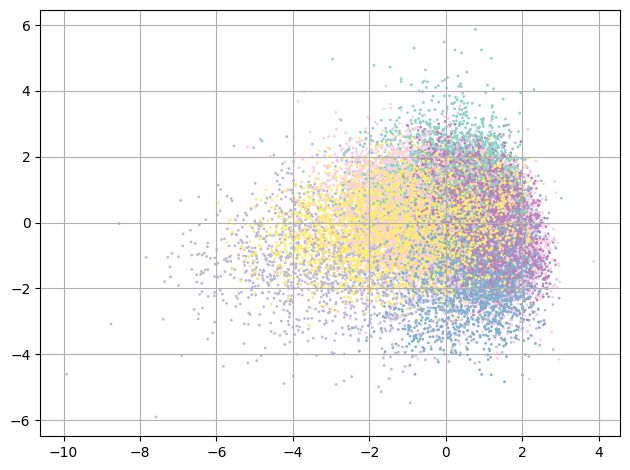

In [54]:
K = 6
cmap = plt.get_cmap('Set3', K)

# --- #

gmm = GaussianMixture(n_components=K, n_init=3)
clusters_gmm = gmm.fit_predict(projected)

# --- #

plt.scatter(projected[:,0], projected[:,1], c=clusters_gmm, s=1, linewidths=1, cmap=cmap)
plt.grid(True)

plt.tight_layout()

# Matrices de confusion sur les différentes méthodes de clustering

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def correspondence_score(classif1, classif2):
    cm = confusion_matrix(classif1, classif2)
    total = np.sum(cm)
    sum = 0
    for i in range(6):
        max_idx = np.unravel_index(np.argmax(cm), cm.shape)
        sum += cm[max_idx]
        # Remove row
        cm = np.delete(cm, max_idx[0], axis=0)
        # Remove column
        cm = np.delete(cm, max_idx[1], axis=1)
    return sum/total

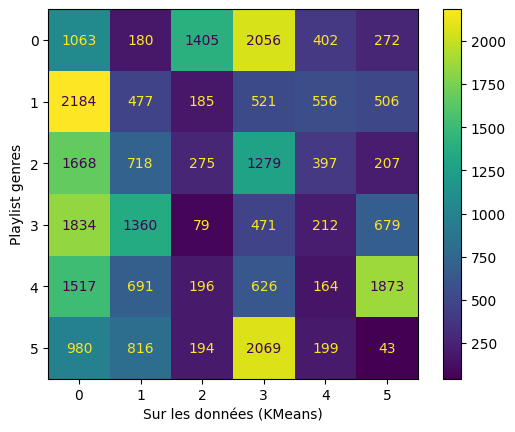

Score de correspondance pour KMeans : 32.757282923044365%


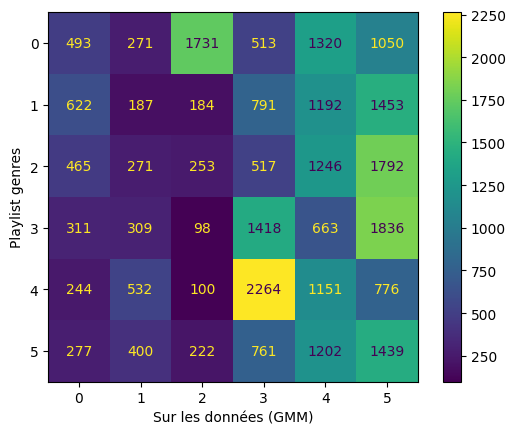

Score de correspondance pour GMM : 28.56387105875714%


In [56]:
ConfusionMatrixDisplay(confusion_matrix(playlist_genre_num, clusters_pca)).plot()
plt.xlabel('Sur les données (KMeans)')
plt.ylabel('Playlist genres')
plt.show()
print("Score de correspondance pour KMeans : " + str(100*correspondence_score(playlist_genre_num, clusters_pca)) + "%")
"""
ConfusionMatrixDisplay(confusion_matrix(playlist_genre_num, clusters_ac)).plot()
plt.xlabel('Sur les données (CAH)')
plt.ylabel('Playlist genres')
plt.show()
print("Score de correspondance pour CAH : " + str(100*correspondence_score(playlist_genre_num, clusters_gmm)) + "%")
"""

ConfusionMatrixDisplay(confusion_matrix(playlist_genre_num, clusters_gmm)).plot()
plt.xlabel('Sur les données (GMM)')
plt.ylabel('Playlist genres')
plt.show()
print("Score de correspondance pour GMM : " + str(100*correspondence_score(playlist_genre_num, clusters_gmm)) + "%")

Les différentes méthodes de clustering ne semblent pas efficaces pour retrouver les genres de `playlist_genre`. Même en imposant 6 classes qui est égal au nombre de genres différents, les matrices de confusion montrent une incapacité à relier les deux. Nous allons donc nous tourner vers les autres variables quantitatives de notre jeu de données pour prédire le genre.

### Interprétation des clusters avec une MCA

Si les clusters ne correspondent pas au genre, on peut se poser la question de ce qu'ils regroupent. On va donc réaliser une MCA en discrétisant certaines des variables quantitatives pour essayer de comprendre ce que représente les clusters.

On créé une nouvelle variable qualitative sur le tempo pour pouvoir réaliser une MCA en considérant cette variable. On choisit de le découper de la manière suivante   
tempo :

- larghissimo : <40
- largo : 40-60
- adagio : 60-80
- andante : 80-100
- allegretto : 100-120
- vivace : 120-140
- presto : 140-188
- prestissimo : >188

In [ ]:
song_CA=song[["playlist_genre","track_album_release_year"]].copy()
popularity=[]

for pop in (song["track_popularity"]):
    popularity.append(int(pop/10))
song_CA.insert(1,"popularity_class",popularity)
song_CA["popularity_class"] = song_CA["popularity_class"].astype('category')

In [ ]:
song_MCA=song_CA.copy()
popularity=[]
song_MCA = song_MCA.drop('track_album_release_year', axis=1)
song_MCA = song_MCA.drop('popularity_class', axis=1)

popularity=[]
for pop in (song["track_popularity"]):
    popularity.append(int(pop/25))
tempol = []
for tempo in (song["tempo"]):
    tempol.append(int(tempo/40))

if 'popularity_class' not in song_MCA.columns:
    song_MCA.insert(1,"popularity_class",popularity)
    song_MCA["popularity_class"] = song_MCA["popularity_class"].astype('category')
if 'tempo' not in song_MCA.columns:
    song_MCA.insert(1,"tempo",tempol)
    song_MCA["tempo"] = song_MCA["tempo"].astype('category')
#song_MCA['mode'] = song['mode']
#song_MCA['key'] = song['key']

print(song_MCA)
#song_MCA_tab=pd.crosstab(song_MCA["popularity_class"], song_MCA["playlist_genre"])
#print(song_MCA_tab)

In [ ]:


mca = prince.MCA(
    n_components=10,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mca = mca.fit(song_MCA)
mca.eigenvalues_summary



In [ ]:


mca.column_contributions_.style.format('{:.0%}')





Dimension 1 : genre EDM, tempo entre 80 et 160 BPM

Dimension 2 : genre pop / RnB, popularité entre 60 et 80

Dimension 3 : genres RnB, rap et rock, tempo entre 120 et 160 BPM, popularité entre 40 et 80

Dimension 4 : genre latino, tempo entre 40 et 80 BPM

Dimension 5 : genres rap et rock, popularité entre 0 et 40

...

Remarques globales :

On constate certaines associations entre genres et tempo caractéristiques. Ainsi le genre EDM est associé à un tempo moyen, le RnB à un tempo plus important et la musique latino à un tempo plus lent et mesuré.

On constate aussi certaines proximités entre genres : les genres Pop et RnB sont assez proches (logique musicalement), le rap et le rock sont aussi assez proches (logique en terme de popularité, ce sont des genres assez populaires). A l'inverse les genres EDM et Latino qui sont assez spéciaux sont plus éloignés.

Les contributions à la sixième dimension, à laquelle contribuent essentiellement les musiques les plus populaires, semble indiquer que ces dernières ont des tempos assez élevés en moyenne.


## Avec des méthodes supervisés?

## Linear Discriminant Analysis

In [51]:
song_LDA = song.copy()
song_LDA.drop('track_artist', axis = 1, inplace = True)
song_LDA.drop('track_popularity', axis = 1, inplace = True)
song_LDA.drop('track_album_name', axis = 1, inplace = True)
song_LDA.drop('playlist_name', axis = 1, inplace = True)
song_LDA.drop('track_album_release_year', axis = 1, inplace = True)
song_LDA.drop('track_album_release_month', axis = 1, inplace = True)
song_LDA.drop('playlist_subgenre', axis = 1, inplace = True)
song_LDA.head()

,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194.754
1,pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162.600
2,pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176.616
3,pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169.093
4,pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189.052


We decide to perform a LDA to try to guess the genre using only physical song properties. Thus we drop all other variables.

In [52]:
"""
PG = song_LDA['playlist_genre'].unique()
PG_names = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']

for i, pg in enumerate(PG):
    data[DPT_names[i]] = 0
    data.loc[data['Department']==dpt, DPT_names[i]] = 1
    data[DPT_names[i]] = data[DPT_names[i]].astype('int')

data = data.drop('Department',axis=1)
# data.head()
"""

"\nPG = song_LDA['playlist_genre'].unique()\nPG_names = ['edm', 'latin', 'pop', 'r&b', 'rap', 'rock']\n\nfor i, pg in enumerate(PG):\n    data[DPT_names[i]] = 0\n    data.loc[data['Department']==dpt, DPT_names[i]] = 1\n    data[DPT_names[i]] = data[DPT_names[i]].astype('int')\n\ndata = data.drop('Department',axis=1)\n# data.head()\n"

In [53]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = song_LDA.drop(['playlist_genre'],axis=1)
X = sc.fit_transform(X)

Y = song_LDA['playlist_genre']

train_data, test_data, train_genre, test_genre = train_test_split(X, Y, test_size=0.3, random_state=20)

clf = LinearDiscriminantAnalysis()
clf.fit(train_data, train_genre)

# --- #

pred_genre = clf.predict(test_data)

accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

Accuracy: 46.81 %
 
              precision    recall  f1-score   support

         edm       0.55      0.54      0.55      1413
       latin       0.37      0.32      0.35      1294
         pop       0.34      0.37      0.36      1536
         r&b       0.41      0.36      0.38      1286
         rap       0.54      0.58      0.56      1621
        rock       0.56      0.61      0.59      1356

    accuracy                           0.47      8506
   macro avg       0.46      0.46      0.46      8506
weighted avg       0.47      0.47      0.47      8506



We observe that we do not manage to accurately guess the song genre based on its physical proprties with the LDA. Indeed, in more than half the cases, the LDA fails to predict the genre.

## QDA

In [54]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

X = song_LDA.drop(['playlist_genre'],axis=1)
X = sc.fit_transform(X)
Y = song_LDA['playlist_genre']

clf = QuadraticDiscriminantAnalysis()
clf.fit(train_data, train_genre)

# --- #

pred_genre = clf.predict(test_data)

accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

Accuracy: 48.2 %
 
              precision    recall  f1-score   support

         edm       0.59      0.61      0.60      1413
       latin       0.43      0.23      0.30      1294
         pop       0.34      0.46      0.39      1536
         r&b       0.41      0.44      0.43      1286
         rap       0.57      0.51      0.54      1621
        rock       0.58      0.63      0.60      1356

    accuracy                           0.48      8506
   macro avg       0.49      0.48      0.48      8506
weighted avg       0.49      0.48      0.48      8506



Quadratic Discriminant Analysis does not provide better results.

In [56]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(solver='newton-cholesky')
clf.fit(train_data, train_genre)

# --- #

pred_genre = clf.predict(test_data)

accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

Accuracy: 47.47 %
 
              precision    recall  f1-score   support

         edm       0.54      0.59      0.57      1413
       latin       0.40      0.30      0.34      1294
         pop       0.36      0.34      0.35      1536
         r&b       0.41      0.39      0.40      1286
         rap       0.53      0.57      0.55      1621
        rock       0.56      0.63      0.60      1356

    accuracy                           0.47      8506
   macro avg       0.47      0.47      0.47      8506
weighted avg       0.47      0.47      0.47      8506



## kNN

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
# Optimisation de k
# grille de valeurs
param_grid=[{"n_neighbors":list(range(1,15))}]
knn=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,n_jobs=-1)
knnOpt=knn.fit(train_data, train_genre)  # GridSearchCV est lui même un estimateur
# paramètre optimal
pred_genre = knn.predict(test_data)


accuracy = accuracy_score(test_genre, pred_genre, normalize=True, sample_weight=None)
print('Accuracy:',round(100*accuracy,2), '%')
print(' ')

# --- #

print(classification_report(test_genre, pred_genre))

knnOpt.best_params_["n_neighbors"]
print("Meilleur score = %f, Meilleur paramètre = %s" % (1.-knnOpt.best_score_,knnOpt.best_params_))

Accuracy: 48.4 %
 
              precision    recall  f1-score   support

         edm       0.54      0.66      0.59      1413
       latin       0.40      0.36      0.38      1294
         pop       0.35      0.37      0.36      1536
         r&b       0.41      0.40      0.40      1286
         rap       0.59      0.55      0.57      1621
        rock       0.62      0.55      0.59      1356

    accuracy                           0.48      8506
   macro avg       0.48      0.48      0.48      8506
weighted avg       0.49      0.48      0.48      8506

Meilleur score = 0.515469, Meilleur paramètre = {'n_neighbors': 14}


> La précision n'est toujours pas très bonne.

## CA et test du $\chi^2$

In [67]:
song_CA=song[["playlist_genre","track_album_release_year"]].copy()
popularity=[]

for pop in (song["track_popularity"]):
    popularity.append(int(pop/10))
song_CA.insert(1,"popularity_class",popularity)
song_CA["popularity_class"] = song_CA["popularity_class"].astype('category')

song_CA_tab=pd.crosstab(song_CA["popularity_class"], song_CA["playlist_genre"])

In [58]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(song_CA_tab)

print(f"Statistique du Chi-2 : {chi2_stat:.4f}")
print(f"P-value : {p_value:.4f}")
print(f"Degrés de liberté : {dof}")


Statistique du Chi-2 : 2236.8943
P-value : 0.0000
Degrés de liberté : 50


On rejette l'hypothèse d'indépendance, (p-valeur nulle). Il y a donc une dépendance entre le genre de la playlist et sa popularité. 

In [59]:
ca=prince.CA(n_components=2)
ca=ca.fit(song_CA_tab)

In [60]:
ca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.059,74.44%,74.44%
1,0.013,16.56%,91.00%


In [61]:
ca.row_coordinates(song_CA_tab)

,0,1
popularity_class,,
0,-0.168892,-0.016291
1,-0.202022,0.146753
2,-0.299521,0.152209
3,-0.187473,0.056353
4,-0.051965,-0.088360
5,0.096105,-0.114708
6,0.276568,-0.067496
7,0.450443,0.075763
8,0.766927,0.453546


On remarque que plus la musique est populaire, plus elle aura tendance à avoir une grande coordonnée selon chacun des axes.

In [62]:
ca.column_coordinates(song_CA_tab)

,0,1
playlist_genre,,
edm,-0.433084,0.089794
latin,0.085041,-0.107986
pop,0.340576,0.179565
r&b,-0.135379,0.027282
rap,0.079426,-0.123665
rock,0.044969,-0.085518


Selon notre hypothèse que la composante 0 est corrélée à la popularité, la pop est plus populaire que les autres genre et edm est moins populaire.

In [63]:
ca.plot(song_CA_tab)

alt.LayerChart(...)

In [64]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(song_CA_tab)

print(f"Statistique du Chi-2 : {chi2_stat:.4f}")
print(f"P-value : {p_value:.4f}")
print(f"Degrés de liberté : {dof}")

Statistique du Chi-2 : 2236.8943
P-value : 0.0000
Degrés de liberté : 50


In [65]:
ca=prince.CA(n_components=10)
ca=ca.fit(song_CA_tab)

In [66]:
ca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.059,74.44%,74.44%
1,0.013,16.56%,91.00%
2,0.006,7.44%,98.44%
3,0.001,1.15%,99.59%
4,0.000,0.41%,100.00%


In [67]:
ca.row_coordinates(song_CA_tab)

,0,1,2,3,4
popularity_class,,,,,
0,-0.168892,-0.016291,-0.067079,-0.025892,-0.019862
1,-0.202022,0.146753,-0.077786,0.023366,0.033209
2,-0.299521,0.152209,-0.027092,0.038777,-0.023419
3,-0.187473,0.056353,0.057957,-0.018089,0.025159
4,-0.051965,-0.088360,0.114329,-0.017668,-0.003608
5,0.096105,-0.114708,0.028222,0.040563,-0.001986
6,0.276568,-0.067496,-0.084596,0.015461,0.010230
7,0.450443,0.075763,-0.051383,-0.053962,0.000637
8,0.766927,0.453546,0.204029,0.031328,-0.045966


## Retrouver la décennie d'un titre en fonction de ses caractéristiques physiques : possible?

In [71]:
song_dec = song.copy()
#song_MCA = song_MCA.drop('track_album_release_year', axis=1)
song_dec = song_dec.drop("track_artist", axis = 1)
song_dec = song_dec.drop("track_popularity", axis = 1)
song_dec = song_dec.drop("track_album_name", axis = 1)
song_dec = song_dec.drop("playlist_name", axis = 1)
song_dec = song_dec.drop("track_album_release_month", axis = 1)
song_dec = song_dec.drop("playlist_genre", axis = 1)
song_dec = song_dec.drop("playlist_subgenre", axis = 1)
song_dec['track_album_release_year'] = song_dec['track_album_release_year'].astype('int')
song_dec.info()
song_dec.head()

<class 'pandas.core.frame.DataFrame'>
Index: 28352 entries, 0 to 28355
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   danceability              28352 non-null  float64 
 1   energy                    28352 non-null  float64 
 2   key                       28352 non-null  category
 3   loudness                  28352 non-null  float64 
 4   mode                      28352 non-null  category
 5   speechiness               28352 non-null  float64 
 6   acousticness              28352 non-null  float64 
 7   instrumentalness          28352 non-null  float64 
 8   liveness                  28352 non-null  float64 
 9   valence                   28352 non-null  float64 
 10  tempo                     28352 non-null  float64 
 11  track_album_release_year  28352 non-null  int64   
 12  duration_s                28352 non-null  float64 
dtypes: category(2), float64(10), int64(1)
memory usage:

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_album_release_year,duration_s
0,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,2019,194.754
1,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,2019,162.600
2,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,2019,176.616
3,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,2019,169.093
4,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,2019,189.052


Un problème que nous avons est que notre jeu de données n'est pas uniforme en terme d'années représentées. En effet comme vu précédemment les années >= 2010 sont sur-représentées par rapport aux autres. Cela pose problème car le régresseur que l'on va créer risquerait de toujours proposer des années entre 2000 et 2020. Il aurait ainsi de bonnes performances théoriques mais ne serait pas satisfaisant car ne prenant pas vraiment en compte les années 50 à 2000 qui nous intéressent. On va donc se restreindre aux musiques dont l'année de sortie est avant 2000.

In [72]:
song_dec = song_dec[song_dec['track_album_release_year'] <= 2000]
song_dec['key'] = song_dec['key'].astype(int)
song_dec['mode'] = song_dec['mode'].astype(int)
song_dec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4319 entries, 749 to 27949
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   danceability              4319 non-null   float64
 1   energy                    4319 non-null   float64
 2   key                       4319 non-null   int64  
 3   loudness                  4319 non-null   float64
 4   mode                      4319 non-null   int64  
 5   speechiness               4319 non-null   float64
 6   acousticness              4319 non-null   float64
 7   instrumentalness          4319 non-null   float64
 8   liveness                  4319 non-null   float64
 9   valence                   4319 non-null   float64
 10  tempo                     4319 non-null   float64
 11  track_album_release_year  4319 non-null   int64  
 12  duration_s                4319 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 472.4 KB


On opère une analyse multifactorielle sur le jeu de données privé de la variable année de sortie, avec les groupes suivants :
- caractéristiques physiques calculées par Spotify (danceability, speechiness, ...) dont les méthodes de calcul ne sont pas connues
- caractéristiques musicales (variables key et mode)
- durée
- tempo

In [73]:
song_dec_wy = song_dec.drop("track_album_release_year", axis = 1)
dict_indexes = {
    "physical" : ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"],
    "music" : ["key", "mode"],
    "duration" : ["duration_s"],
    "tempo" : ["tempo"]
}
mfa = prince.MFA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(
    song_dec_wy, groups = dict_indexes
)

In [74]:
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.159,15.68%,15.68%
1,1.053,14.25%,29.93%
2,1.040,14.08%,44.01%
3,0.899,12.17%,56.18%
4,0.657,8.90%,65.08%
5,0.594,8.04%,73.11%
6,0.523,7.07%,80.19%


In [75]:
data_train, data_test, y_train, y_test = train_test_split(
    mfa.row_coordinates(song_dec_wy), song_dec["track_album_release_year"], test_size=0.33, random_state=42)

print(mfa.row_coordinates(song_dec_wy).shape)
print(song_dec["track_album_release_year"].shape)
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
regr = linear_model.LinearRegression()
regr.fit(data_train, y_train)
# Make predictions using the testing set
y_pred = regr.predict(data_test)
print(y_pred)
print(y_test)
# The mean squared error
print(np.mean(abs(y_pred - y_test)))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

(4319, 7)
(4319,)
[1991.25227517 1987.29150827 1993.8743536  ... 1988.79765759 1985.97799386
 1987.04174049]
6542     1996
23387    1975
7720     1998
3139     1998
2332     1995
         ... 
12501    1967
22053    1999
10754    1999
11885    1974
11526    1982
Name: track_album_release_year, Length: 1426, dtype: int64
6.812118084648919
Mean squared error: 70.57
Coefficient of determination: 0.18


In [76]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100, 1000], cv=5)  
ridge_cv.fit(data_train, y_train)
print(ridge_cv.alpha_)
y_pred = ridge_cv.predict(data_test)
print("Model score (R^2):", r2_score(y_test, y_pred))

10.0
Model score (R^2): 0.17696032189578115


In [77]:
from sklearn.linear_model import LassoCV
reg = LassoCV(cv=100, random_state=0).fit(mfa.row_coordinates(song_dec_wy), song_dec["track_album_release_year"])
reg.score(mfa.row_coordinates(song_dec_wy), song_dec["track_album_release_year"])

0.17123861352161152

In [78]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import make_scorer 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score

param_grid = {'max_depth': range(1, 16)}
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=10)
grid_search.fit(data_train, y_train)
best_depth = grid_search.best_params_['max_depth']
print(f"Method 4: Best Depth found by Grid Search is {best_depth}")
model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
model.fit(data_train, y_train)
y_pred = model.predict(data_test)
print(y_pred)
print(np.mean(abs(y_pred - y_test)))
print("Model score (R^2):", r2_score(y_test, y_pred))

Method 4: Best Depth found by Grid Search is 5
[1993.99358974 1988.65112994 1995.23178808 ... 1986.55580357 1984.63909774
 1986.55580357]
6.795608361499333
Model score (R^2): 0.13324591061756708


In [79]:
from sklearn.ensemble import RandomForestRegressor

param=[{"max_features":list(range(2,10,1))}]
rf= GridSearchCV(RandomForestRegressor(n_estimators=100),
        param,cv=5,n_jobs=-1)
    
rf.fit(data_train, y_train)
y_pred = rf.predict(data_test)

print(y_pred)
print(np.mean(abs(y_pred - y_test)))
print("Model score (R^2):", r2_score(y_test, y_pred))

[1993.18 1988.35 1995.5  ... 1985.84 1986.83 1985.52]
6.248996168102588
Model score (R^2): 0.2696368833699535


In [80]:
#pip install xgboost

In [81]:
import xgboost as xgb
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(data_train, y_train)
y_pred = model.predict(data_test)

print(y_pred)
print(np.mean(abs(y_pred - y_test)))
print("Model score (R^2):", r2_score(y_test, y_pred))

[1996.1813 1982.0133 1996.9337 ... 1987.8906 1982.1311 1983.2616]
6.436576425945608
Model score (R^2): 0.18392819166183472


En conclusion, même en utilisant des modèles de régression assez complexes (Random Forest, XGBoost...), on obtient au mieux des écarts moyens de l'ordre de 6 ans par rapport à la réalité. On a donc un modèle prédictif capable en gros de deviner la bonne décennie pour la chanson à partir de ses propriétés physiques et musicales.

C'est une performance à contraster puisqu'on étudie des musiques des années 60 à 2000 uniquement : en prenant 1980 tout le temps, on aurait "seulement" 20 ans d'écart dans le pire des cas. C'est aussi ce que montrent les faibles R^2 (entre 10% et 20%) : nos modèles ajoutent peu de précision par rapport au choix trivial qui reviendrait à tout le temps prendre la moyenne.

On en conclut donc que les propriétés physiques d'une musique ajoutent bien des informations utiles pour associer celle-ci à une période donnée mais pas suffisamment pour avoir une prédiction précise dans la majorité des cas.

## Les genres sont-ils liés aux caractéristiques physiques d'une musique?

On cherche à voir si le genre d'une musique est une information contenue dans les propriétés physiques d'une musique (tempo, valence, durée etc.), ou si le choix du genre est plus "arbitraire". Pour cela, on sélectionne les propriétés physiques des musiques du jeu de données, on standardise le jeu de données à l'aide d'une MFA, puis on opère un clustering avec un nombre de classes égal au nombre de genres (qui est connu). On réalise ensuite une matrice de confusion et on conclut en évaluant un score de correspondance.

In [161]:
song_ge = song.copy()
#song_MCA = song_MCA.drop('track_album_release_year', axis=1)
song_ge = song_ge.drop("track_artist", axis = 1)
song_ge = song_ge.drop("track_popularity", axis = 1)
song_ge = song_ge.drop("track_album_name", axis = 1)
song_ge = song_ge.drop("playlist_name", axis = 1)
song_ge = song_ge.drop("track_album_release_month", axis = 1)
song_ge = song_ge.drop("track_album_release_year", axis = 1)
song_ge = song_ge.drop("playlist_genre", axis = 1)
song_ge = song_ge.drop("playlist_subgenre", axis = 1)
song_ge = song_ge.drop("duration_s", axis = 1)
song_ge['key'] = song_ge['key'].astype(int)
song_ge['mode'] = song_ge['mode'].astype(int)
song_ge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28352 entries, 0 to 28355
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      28352 non-null  float64
 1   energy            28352 non-null  float64
 2   key               28352 non-null  int64  
 3   loudness          28352 non-null  float64
 4   mode              28352 non-null  int64  
 5   speechiness       28352 non-null  float64
 6   acousticness      28352 non-null  float64
 7   instrumentalness  28352 non-null  float64
 8   liveness          28352 non-null  float64
 9   valence           28352 non-null  float64
 10  tempo             28352 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 2.6 MB


In [162]:
dict_indexes = {
    "physical" : ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"],
    "music" : ["key", "mode"],
    "tempo" : ["tempo"]
}
mfa = prince.MFA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(
    song_ge, groups = dict_indexes
)
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.158,17.94%,17.94%
1,1.010,15.64%,33.59%
2,0.882,13.67%,47.26%
3,0.705,10.93%,58.18%
4,0.655,10.14%,68.33%
5,0.504,7.81%,76.14%
6,0.458,7.09%,83.23%


In [90]:
#data_train, data_test, g_train, g_test = train_test_split(mfa.row_coordinates(song_ge), song["playlist_genre"] , test_size=0.33, random_state=0)

In [185]:
mfa_data = mfa.row_coordinates(song_ge)

from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=6)
clusters_gmm = gmm.fit_predict(mfa_data)

In [129]:
def correspondence_score(classif1, classif2):
    cm = confusion_matrix(classif1, classif2)
    total = np.sum(cm)
    sum = 0
    for i in range(6):
        max_idx = np.unravel_index(np.argmax(cm), cm.shape)
        sum += cm[max_idx]
        # Remove row
        cm = np.delete(cm, max_idx[0], axis=0)
        # Remove column
        cm = np.delete(cm, max_idx[1], axis=1)
    return sum/total

In [181]:
# Create mapping
genre_map = {'edm': 0, 'latin': 1, 'pop': 2, 'r&b': 3, 'rap': 4, 'rock': 5}

# Map the values
genres_mapped = song['playlist_genre'].map(genre_map)

In [187]:
avg_score = 0
for i in range(10):
    gmm = GaussianMixture(n_components=6)
    clusters_gmm = gmm.fit_predict(mfa_data)
    avg_score += correspondence_score(genres_mapped, clusters_gmm)
avg_score = avg_score/10
print(avg_score)

0.22528216704288936


On obtient un score de correspondence moyen de 22.6% entre les clusters obtenus par modèle de mélange gaussien et les classes correspondant aux genres des musiques. Ce n'est pas très satisfaisant et semble indiquer que les caractéristiques physiques d'une musique ne permettent pas de connaître son genre : un robot, par exemple, qui aurait uniquement accès à ses caractéristiques-là en écoutant la musique, ne pourrait pas savoir s'il écoute du rap, de l'edm etc.

Essayons de calculer un équivalent du "No-Information Rate" pour voir si l'on gagne tout de même en information en connaissant les caractéristiques physiques.

In [124]:
print(len(song[song["playlist_genre"] == "rap"])/len(song))

0.19039221218961624


En associant bêtement toutes les musiques au genre le plus populaire dans le jeu de données (c'est-à-dire le rap), on aurait bon dans 19.0% des cas, ce qui est à peine moins bon que le score de correspondence obtenu précédemment !

Cela suggère que les caractéristiques physiques d'une musique apportent vraiment peu d'informations sur son genre. 

On peut apporter plusieurs explications à cela :

- une musique peut appartenir à plusieurs genres, en revanche dans le jeu de données elle n'est comptabilisée qu'une fois pour un seul genre. Ainsi les classes "rap" et "r&b" sont dissociées dans le jeu de données, mais elles ne le sont pas nécessairement dans la vraie vie.
  
- on ne connaît pas ce qui se cache derrière l'attribution du genre. S'il est fait par un humain entre autres, rien n'empêche quelqu'un de considérer que sa musique est du "rap" même si elle ne respecte pas les codes sous-jacents. 
  
- les genres de musiques ne sont pas bien définis, même de façon purement théorique. Qu'est-ce qui fait qu'une musique est du "rap" ou de la "pop"? Sans oublier que cela change selon les époques, le rap des années 90 ne ressemble pas tout à fait au rap des années 2010, pourtant ils ont la même étiquette dans le jeu de données. On pourrait voir si l'on obtient des meilleurs résultats en sélectionnant uniquemment les données d'une certaine période (2000 à 2010 par exemple).

Pour vérifier la validité de cette dernière hypothèse, on peut se restreindre aux musiques entre 2000 et 2010 dans le jeu de données étudié et réitérer notre analyse.

In [188]:
song_gep = song.copy()
song_gep['track_album_release_year'] = song_gep['track_album_release_year'].astype('int')
song_gep = song_gep[song_gep["track_album_release_year"] >= 2000]
song_gep = song_gep[song_gep["track_album_release_year"] <= 2010]
song_gep = song_gep.drop("track_artist", axis = 1)
song_gep = song_gep.drop("track_popularity", axis = 1)
song_gep = song_gep.drop("track_album_name", axis = 1)
song_gep = song_gep.drop("playlist_name", axis = 1)
song_gep = song_gep.drop("track_album_release_month", axis = 1)
song_gep = song_gep.drop("track_album_release_year", axis = 1)
genres_mapped = song_gep['playlist_genre'].map(genre_map)
song_gep = song_gep.drop("playlist_genre", axis = 1)
song_gep = song_gep.drop("playlist_subgenre", axis = 1)
song_gep = song_gep.drop("duration_s", axis = 1)
song_gep['key'] = song_gep['key'].astype(int)
song_gep['mode'] = song_gep['mode'].astype(int)
song_gep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4365 entries, 160 to 28130
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      4365 non-null   float64
 1   energy            4365 non-null   float64
 2   key               4365 non-null   int64  
 3   loudness          4365 non-null   float64
 4   mode              4365 non-null   int64  
 5   speechiness       4365 non-null   float64
 6   acousticness      4365 non-null   float64
 7   instrumentalness  4365 non-null   float64
 8   liveness          4365 non-null   float64
 9   valence           4365 non-null   float64
 10  tempo             4365 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 409.2 KB


In [189]:
mfa = prince.MFA(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)
mfa = mfa.fit(
    song_gep, groups = dict_indexes
)
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.180,18.23%,18.23%
1,1.032,15.94%,34.16%
2,0.936,14.46%,48.62%
3,0.698,10.79%,59.41%
4,0.588,9.08%,68.48%
5,0.528,8.16%,76.64%
6,0.464,7.16%,83.80%


In [190]:
mfa_data = mfa.row_coordinates(song_gep)
avg_score = 0
for i in range(10):
    gmm = GaussianMixture(n_components=6)
    clusters_gmm = gmm.fit_predict(mfa_data)
    avg_score += correspondence_score(genres_mapped, clusters_gmm)
avg_score = avg_score/10
print(avg_score)

0.271340206185567


En utilisant uniquement les musiques entre 2000 et 2010 de notre jeu de données, le score de correspondance est légèrement meilleur que précédemment (27,1% au lieu de 22,5%), mais toujours loin d'être satisfaisant. D'autres facteurs - dont ceux que nous avons identifiés - rentrent donc en compte, au-delà de la période, et sont importants.

Les résultats sont à nuancer : à proprement parler, si l'on voulait deviner le genre à partir des caractéristiques physiques d'une musique, il serait plus adapté de faire une régression logistique par exemple, qui donnerait sensiblement des résultats plus concluants. Ici, on a simplement montré que le genre n'est pas une classification "naturelle" des musiques lorsqu'on dispose uniquement de ses propriétés physiques puisqu'on ne la retrouve pas en faisant un clustering "à l'aveugle".

# Regression linéaire

In [123]:
song_reg = song.drop('track_artist', axis = 1)
song_reg.drop('track_album_name', axis = 1, inplace=True)
song_reg.drop('playlist_name', axis = 1, inplace=True)
song_reg.drop('playlist_subgenre', axis = 1, inplace=True)
song_reg.drop('track_album_release_month', axis = 1, inplace=True)
song_reg.drop('key', axis = 1, inplace=True)
song_reg.drop('track_album_release_year', axis = 1, inplace=True)

song_reg.head()

,track_popularity,playlist_genre,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,66,pop,0.748,0.916,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194.754
1,67,pop,0.726,0.815,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162.600
2,70,pop,0.675,0.931,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176.616
3,60,pop,0.718,0.930,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169.093
4,69,pop,0.650,0.833,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189.052


On retire les variables qualitatives qui ont de nombreuses modalités pour simplifier la régression en limitant le nombre de coefficients.

In [124]:
# variable à expliquer binaire
#Yb=ozone["DepSeuil"].map(lambda x: int(x))
# variable à expliquer réelle
Yr=song_reg["track_popularity"]

song_reg.drop('track_popularity', axis=1, inplace=True)
song_reg.drop('playlist_genre', axis=1, inplace=True)

In [125]:
from sklearn.model_selection import train_test_split  
X_train,X_test,Yr_train,Yr_test=train_test_split(song_reg,Yr,test_size=0.2,random_state=11)

In [126]:
from sklearn.preprocessing import StandardScaler  
# L'algorithme des réseaux de neurones nécessite éventuellement une normalisation 
# des variables explicatives avec les commandes ci-dessous
scaler = StandardScaler()  
scaler.fit(X_train)  
Xr_train = scaler.transform(X_train)  
# Meme transformation sur le test
Xr_test = scaler.transform(X_test)

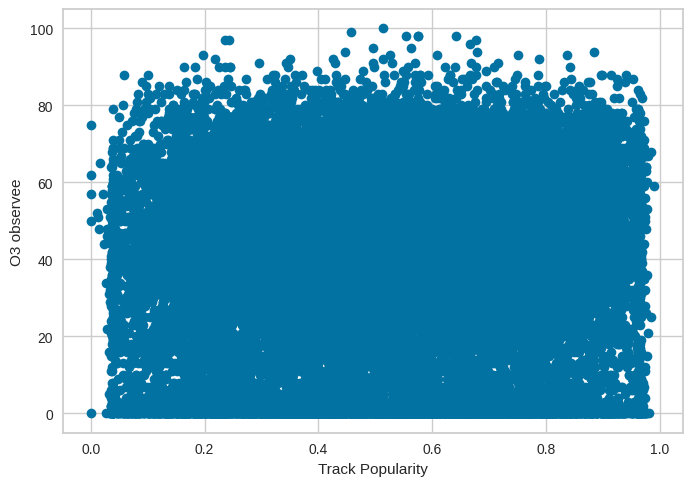

In [128]:
plt.plot(X_train["valence"],Yr_train,"o")
plt.xlabel("Track Popularity")
plt.ylabel("O3 observee")
plt.show()

A faire: deviner le subgenre depuis un genre

# NMF

In [200]:
song_complete.head(100)

,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_album_release_year,track_album_release_month,duration_s
0,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury...,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.10200,0.000000,0.0653,0.518,122.036,2019,6,194.754
1,Maroon 5,67,Memories (Dillon Francis Remix),Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.07240,0.004210,0.3570,0.693,99.972,2019,12,162.600
2,Zara Larsson,70,All the Time (Don Diablo Remix),Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.07940,0.000023,0.1100,0.613,124.008,2019,7,176.616
3,The Chainsmokers,60,Call You Mine - The Remixes,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.02870,0.000009,0.2040,0.277,121.956,2019,7,169.093
4,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.08030,0.000000,0.0833,0.725,123.976,2019,3,189.052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Zedd,84,The Middle,Dance Pop,pop,dance pop,0.753,0.657,7,-3.061,1,0.0449,0.17100,0.000000,0.1120,0.437,107.010,2018,1,184.732
96,NOTD,70,Wanted,Dance Pop,pop,dance pop,0.693,0.674,5,-4.449,1,0.0723,0.18500,0.000000,0.0639,0.378,95.972,2019,9,160.998
97,Steve Aoki,37,Crash Into Me,Dance Pop,pop,dance pop,0.672,0.815,1,-6.476,0,0.0981,0.00246,0.000000,0.5770,0.341,115.033,2019,7,226.093
98,Gryffin,70,Gravity,Dance Pop,pop,dance pop,0.581,0.760,0,-3.962,1,0.0406,0.16000,0.000000,0.1830,0.523,104.099,2019,10,205.787


In [91]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

,track_id,track_name,track_popularity,track_album_id,track_album_release_date,playlist_id,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,66,2oCs0DGTsRO98Gh5ZSl2Cx,2019-06-14,37i9dQZF1DXcZDD7cfEKhW,pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,67,63rPSO264uRjW1X5E6cWv6,2019-12-13,37i9dQZF1DXcZDD7cfEKhW,pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,70,1HoSmj2eLcsrR0vE9gThr4,2019-07-05,37i9dQZF1DXcZDD7cfEKhW,pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,60,1nqYsOef1yKKuGOVchbsk6,2019-07-19,37i9dQZF1DXcZDD7cfEKhW,pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,69,7m7vv9wlQ4i0LFuJiE2zsQ,2019-03-05,37i9dQZF1DXcZDD7cfEKhW,pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## Préparation des données
On garde les données qualitatives, on les normalise et on s'assure qu'elles soient toutes positives.

In [301]:
song_nmf = pd.DataFrame.copy(song.drop('track_artist', axis = 1))
song_nmf.head()
song_nmf.drop('track_album_name', axis = 1, inplace=True)
song_nmf.drop('playlist_name', axis = 1, inplace=True)
song_nmf.drop('playlist_subgenre', axis = 1, inplace=True)
song_nmf.drop('track_album_release_month', axis = 1, inplace=True)
song_nmf.drop('key', axis = 1, inplace=True)
song_nmf.drop('track_album_release_year', axis = 1, inplace=True)
song_nmf.drop('track_popularity', axis = 1, inplace=True)
song_nmf.drop('duration_s', axis = 1, inplace=True)
song_nmf.drop('mode', axis = 1, inplace=True)


#song_nmf = pd.concat([song_nmf, pd.get_dummies(song_nmf['playlist_genre'], prefix='playlist_genre',dtype=int)], axis=1)
song_nmf.drop('playlist_genre', axis = 1, inplace=True)
X_nmf=MinMaxScaler().fit_transform(song_nmf)
song_nmf.head(10)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036
1,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972
2,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976
5,0.675,0.919,-5.385,0.1270,0.0799,0.000000,0.1430,0.585,124.982
6,0.449,0.856,-4.788,0.0623,0.1870,0.000000,0.1760,0.152,112.648
7,0.542,0.903,-2.419,0.0434,0.0335,0.000005,0.1110,0.367,127.936
8,0.594,0.935,-3.562,0.0565,0.0249,0.000004,0.6370,0.366,127.015
9,0.642,0.818,-4.552,0.0320,0.0567,0.000000,0.0919,0.590,124.957


In [302]:
nmf =NMF(n_components=6, init='nndsvda', solver='mu', max_iter=1000)
nmf.fit(X_nmf)
W = nmf.transform(X_nmf)
H = nmf.components_

print("Original data")
print(X_nmf)
print("\nReconstructed data")
print(W.dot(H))
print("\nSquared reconstruction error")
print(np.linalg.norm(W.dot(H) - X_nmf)**2)
print(H.shape)
H_sklearn = H.copy()
W_sklearn = W.copy()

Original data
[[0.76093591 0.9159853  0.91808981 ... 0.06556225 0.52270434 0.50967257]
 [0.73855544 0.81496762 0.86916162 ... 0.35843373 0.69929364 0.41752422]
 [0.68667345 0.93098792 0.90136831 ... 0.11044177 0.6185671  0.51790845]
 ...
 [0.53814852 0.82096867 0.87062842 ... 0.15060241 0.43995964 0.53453475]
 [0.63682604 0.8879804  0.90285607 ... 0.34437751 0.31079717 0.5346141 ]
 [0.61342828 0.8839797  0.87750141 ... 0.74497992 0.09021191 0.53451387]]

Reconstructed data
[[0.7320068  0.83868644 0.92776152 ... 0.2336383  0.54014506 0.54480798]
 [0.70039509 0.84068483 0.86767054 ... 0.22907419 0.69450049 0.46369703]
 [0.67028221 0.87459639 0.90786223 ... 0.23857706 0.63112515 0.53950809]
 ...
 [0.54261251 0.80267332 0.84994725 ... 0.23222001 0.44390286 0.54828353]
 [0.62630876 0.90116699 0.92142144 ... 0.26514761 0.30898718 0.5334446 ]
 [0.53287538 0.98260151 0.94384395 ... 0.3035083  0.12687651 0.55030357]]

Squared reconstruction error
1155.878289549387
(6, 9)


[1 2 8 0 6 7 3 4 5]
[6.25792264e+00 1.69089385e+01 1.51309099e+01 1.09888753e+00
 1.97004495e-05 1.19708331e-08 5.47814159e+00 1.49384439e+00
 8.70807302e+00]
['pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop']
[7 1 0 2 8 4 6 5 3]
[7.23252889e-01 1.66072266e+00 6.36366022e-01 4.23281237e-15
 2.99192772e-02 1.61641233e-06 8.73181276e-04 7.23200739e+00
 5.53495697e-01]
['pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop']
[5 0 1 2 8 6 7 4 3]
[1.10918877e+00 6.26602148e-01 6.04853275e-01 5.59190991e-07
 5.26844647e-04 5.10990500e+00 1.13110826e-02 8.96138172e-04
 4.32440997e-01]
['pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop']
[4 2 6 8 0 3 7 1 5]
[5.05743205e-01 1.51181783e-01 1.68034753e+00 2.93200052e-01
 5.91614076e+00 5.92983555e-10 7.42962413e-01 1.95429394e-01
 6.58753454e-01]
['pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop', 'pop']
[0 7 2 3 1 8 4 6 5]
[3.89794960e+00 5.29348710e-01 1.63070154e+00 1.22422590e+00
 7.59748549e-03 5.24868413e

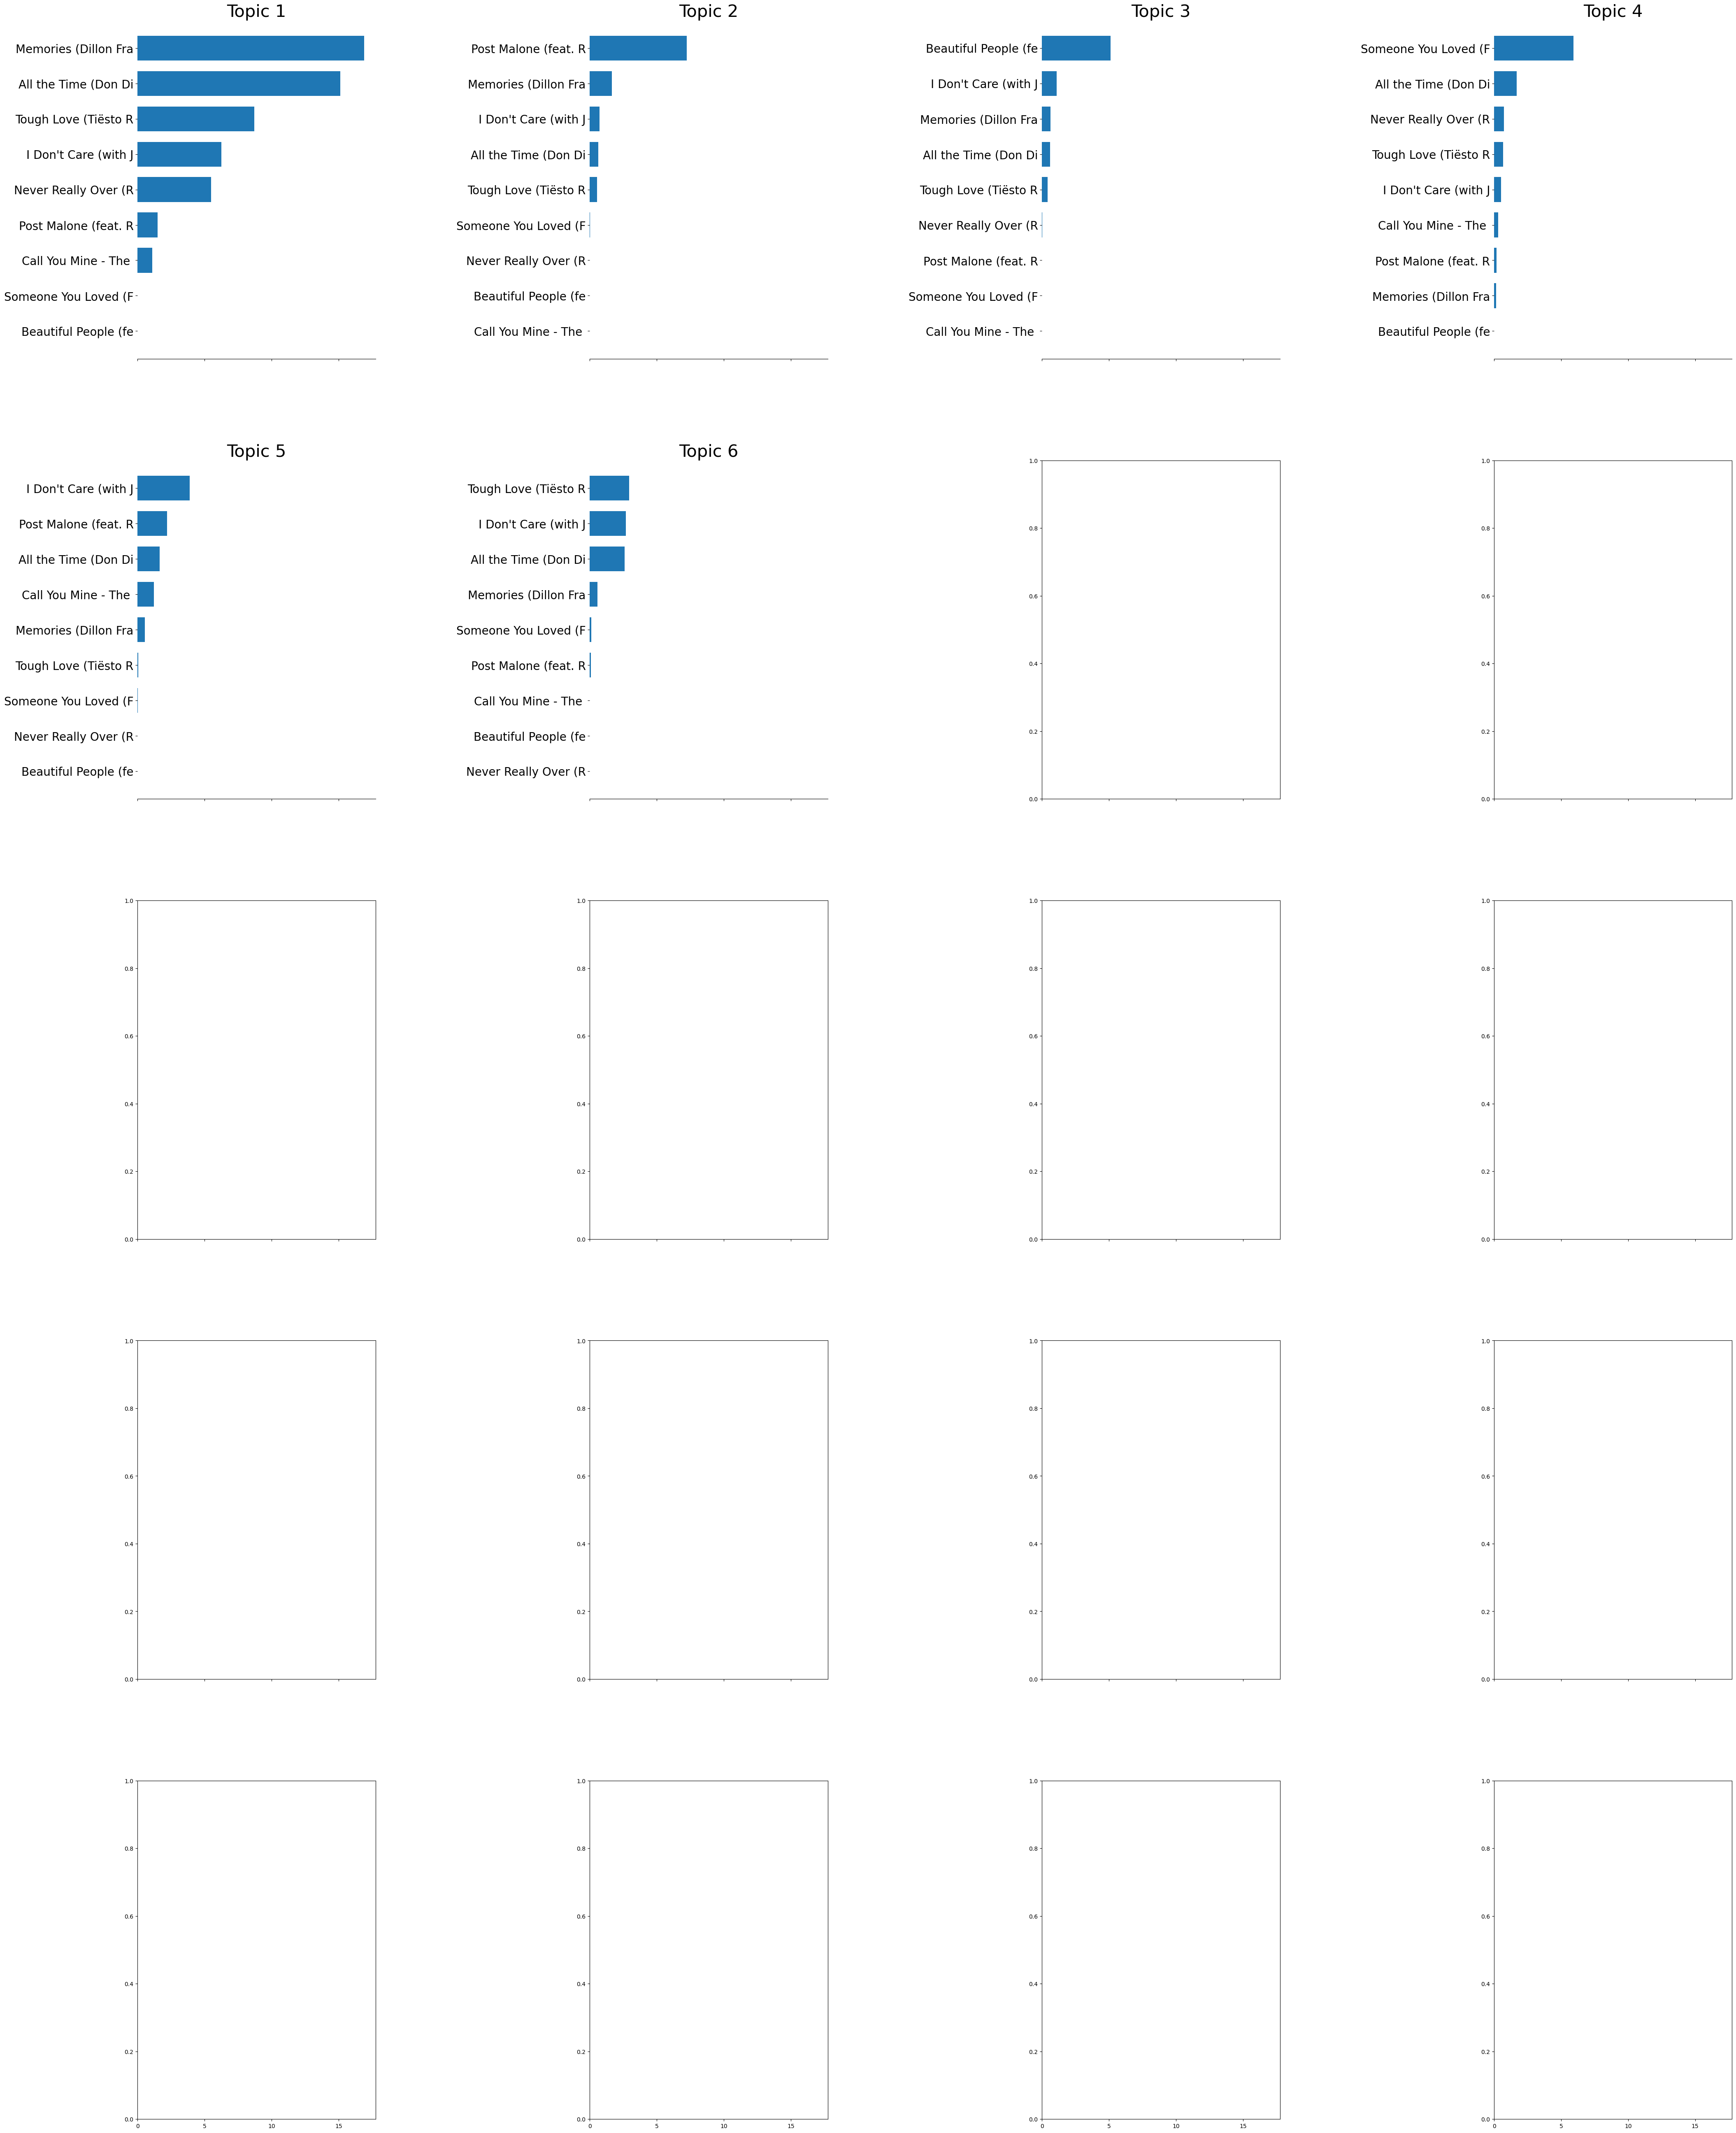

In [303]:
n_top_songs = 20
fig, axes = plt.subplots(5, 4, figsize=(50, 60), sharex=True)
axes = axes.flatten()

for i in range(H.shape[0]):
    topic =H[i,: ]
    top_features = topic.argsort()[: -n_top_songs - 1 : -1]
    print(top_features)
    print(H[i,:])
    top_features_names = [song_complete["track_album_name"][j][:20] for j in top_features]
    top_features_scores = [topic[j] for j in top_features]
    top_features_genres = [song["playlist_genre"][j] for j in top_features]
    print(top_features_genres)
    #top_cmap = colors.ListedColormap(cmap.colors[top_features_genres])
    
    ax = axes[i]
    ax.barh(top_features_names, top_features_scores, height=0.7) #, color=top_cmap.colors)
    ax.set_title(f"Topic {i+1}", fontdict={"fontsize": 30})
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="major", labelsize=20)
    for i in "top right left".split():
        ax.spines[i].set_visible(False)

plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
plt.show()

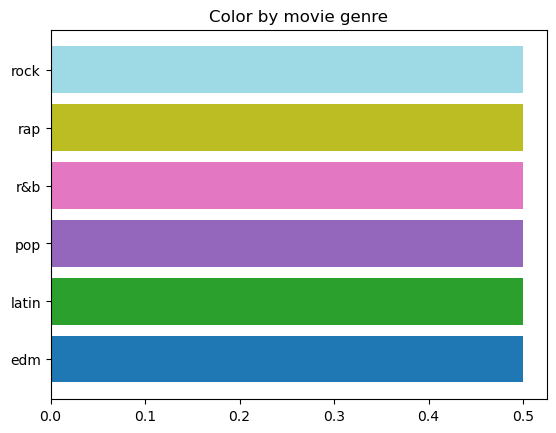

In [304]:
genre = song["playlist_genre"].values
unique_genres = np.unique(genre)
cmap = plt.get_cmap('tab20', len(unique_genres))
genre_to_color = {g: cmap(i) for i, g in enumerate(unique_genres)}


plt.barh(unique_genres, .5, color=cmap.colors, label=unique_genres)

plt.title("Color by movie genre")
plt.show()

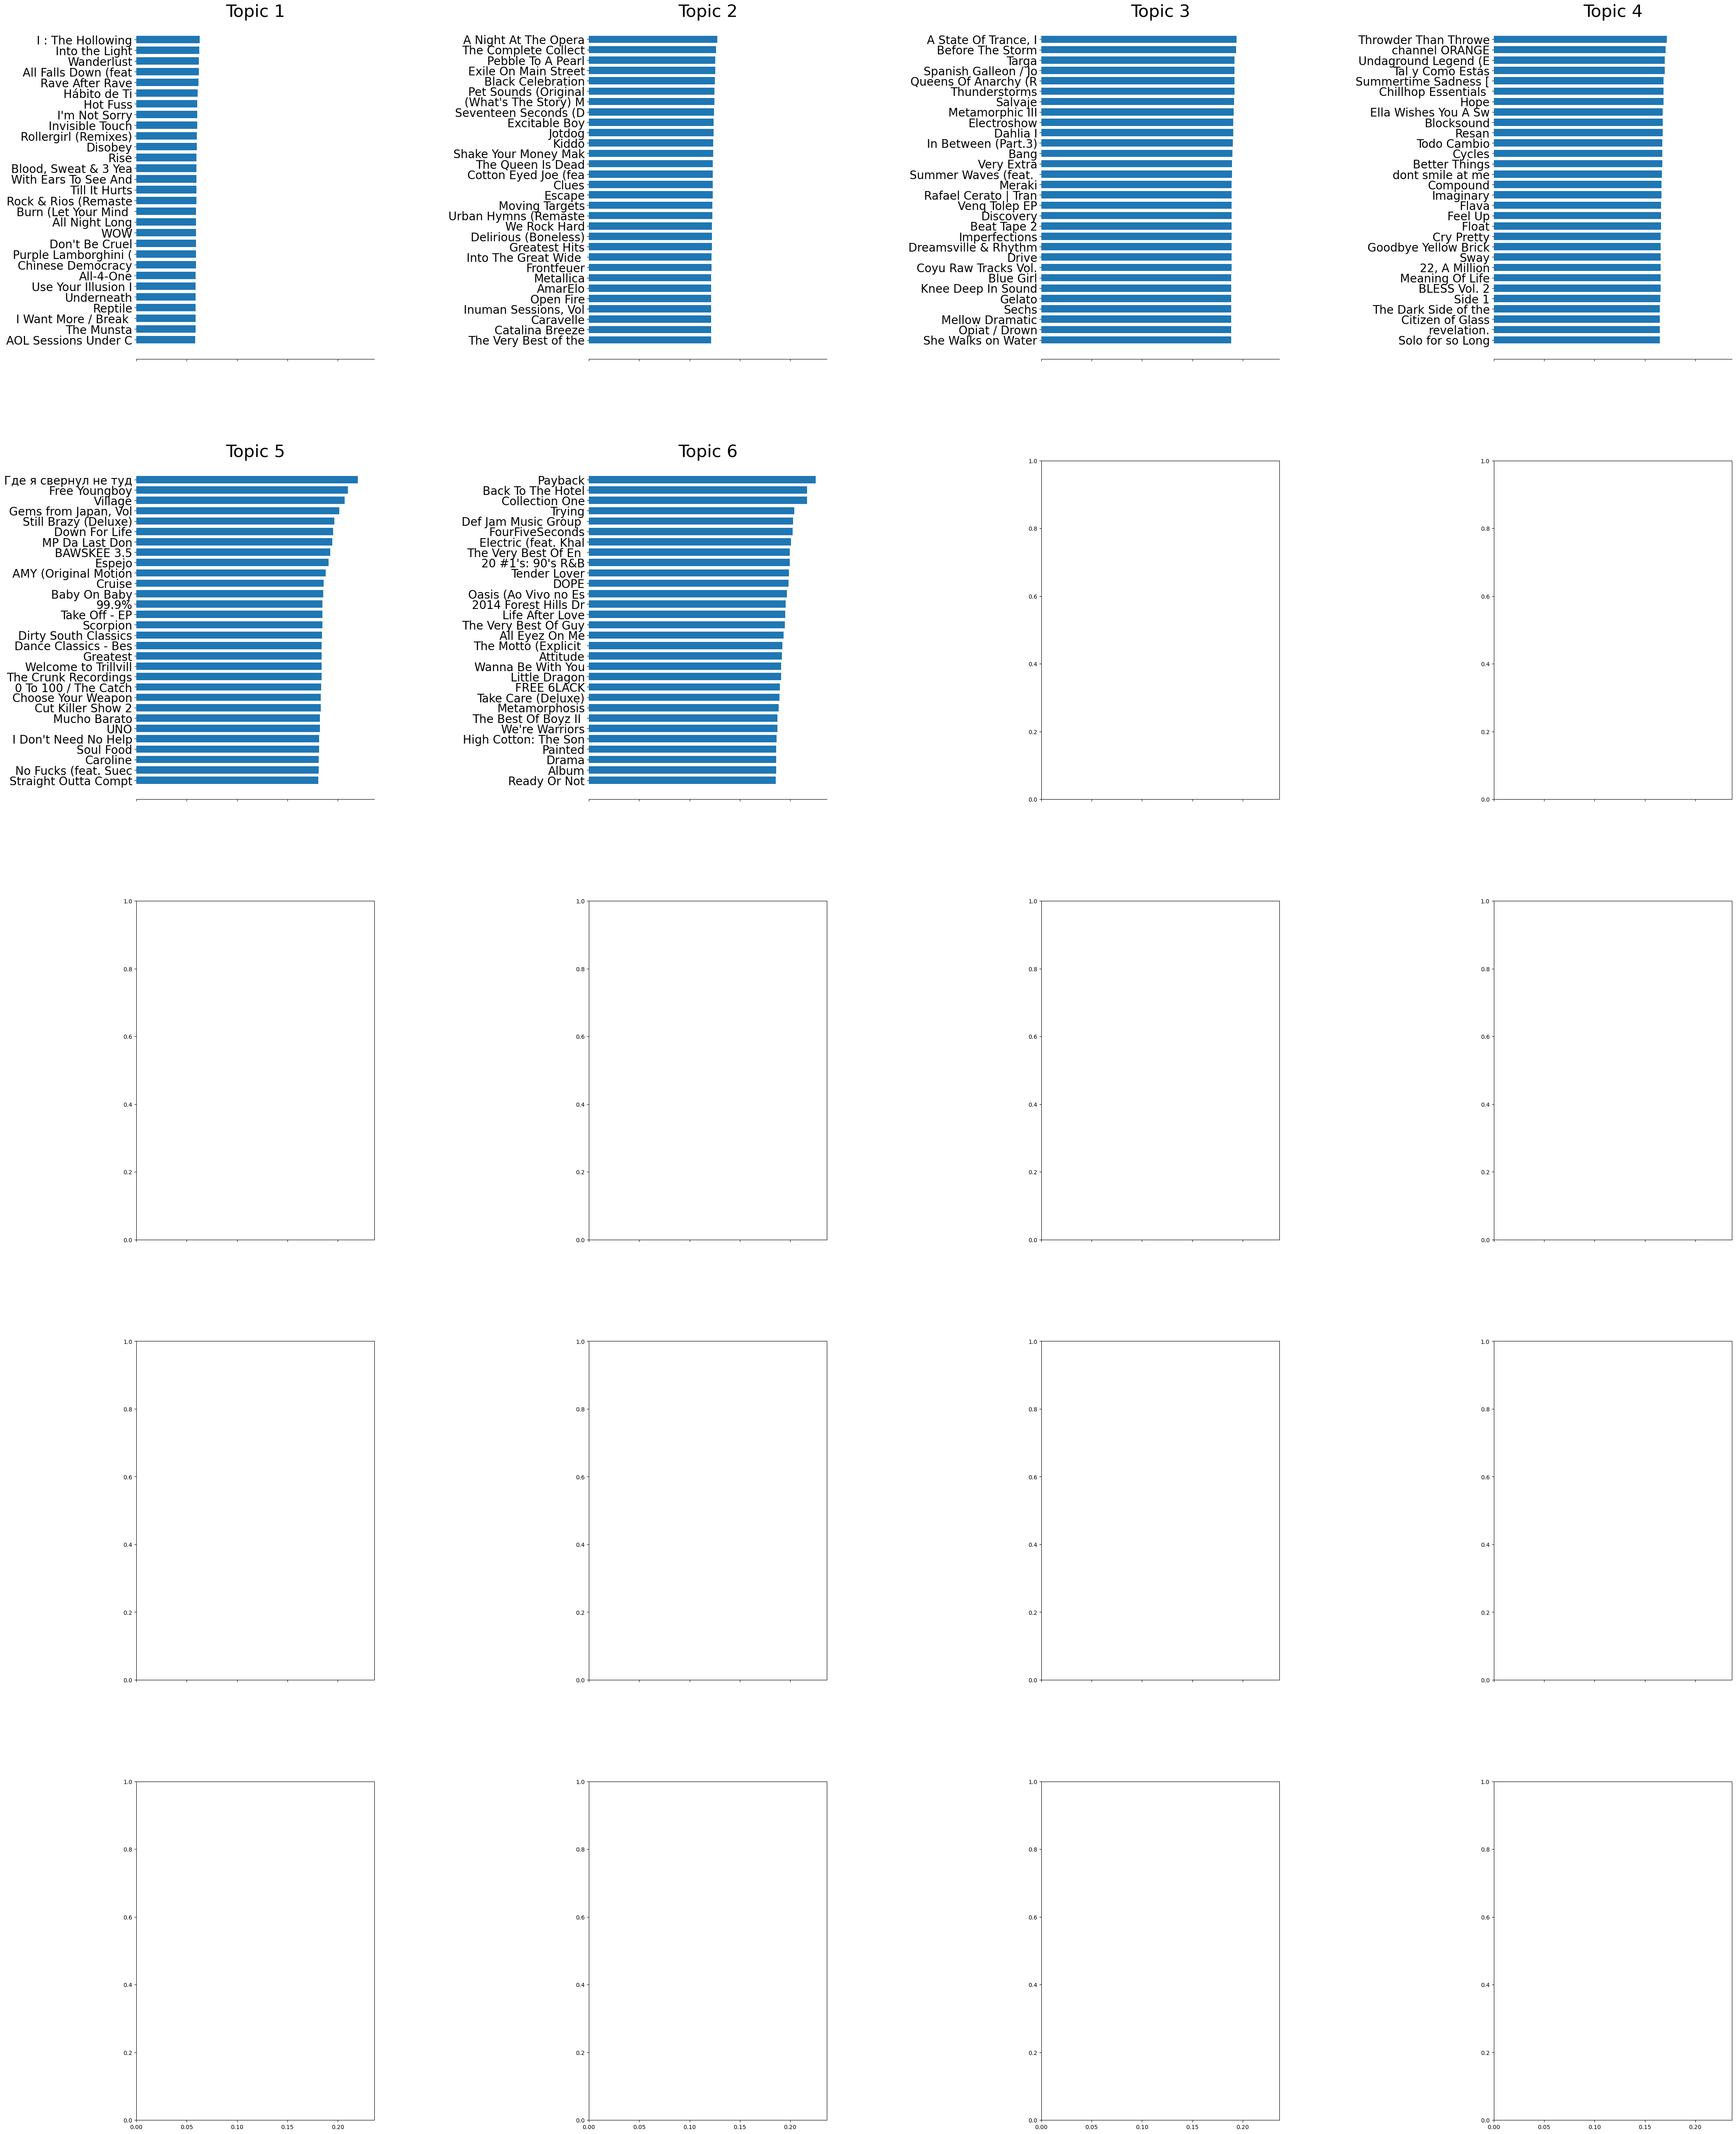

In [309]:
n_top_songs = 30
fig, axes = plt.subplots(5, 4, figsize=(50, 60), sharex=True)
axes = axes.flatten()



for i in range(W.shape[1]):
    topic =W[:,i]
    top_features = topic.argsort()[: -n_top_songs - 1 : -1]
    top_features_names = [song_complete["track_album_name"][j][:20] for j in top_features]
    top_features_scores = [topic[j] for j in top_features]
    top_features_genres = [song["playlist_genre"][j] for j in top_features]
    top_labels = [
        f"{song_complete['track_album_name'].iloc[i][:20]} - {song_complete['track_artist'].iloc[i][:20]}"
        for i in top_features
    ]
    top_features_genres = [genre[i] for i in top_features]
    bar_colors = [genre_to_color[g] for g in top_features_genres]
    ax = axes[i]


    ax.barh(top_features_names, top_features_scores, height=0.7) #, color=top_cmap.colors)
    ax.set_title(f"Topic {i+1}", fontdict={"fontsize": 30})
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="major", labelsize=20)
    for i in "top right left".split():
        ax.spines[i].set_visible(False)

plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
plt.show()
    for i in "top right left".split():
        ax.spines[i].set_visible(False)
    ax.barh(top_labels, top_features_scores, color=bar_colors)
    ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="major", labelsize=20)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)

plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
plt.show()

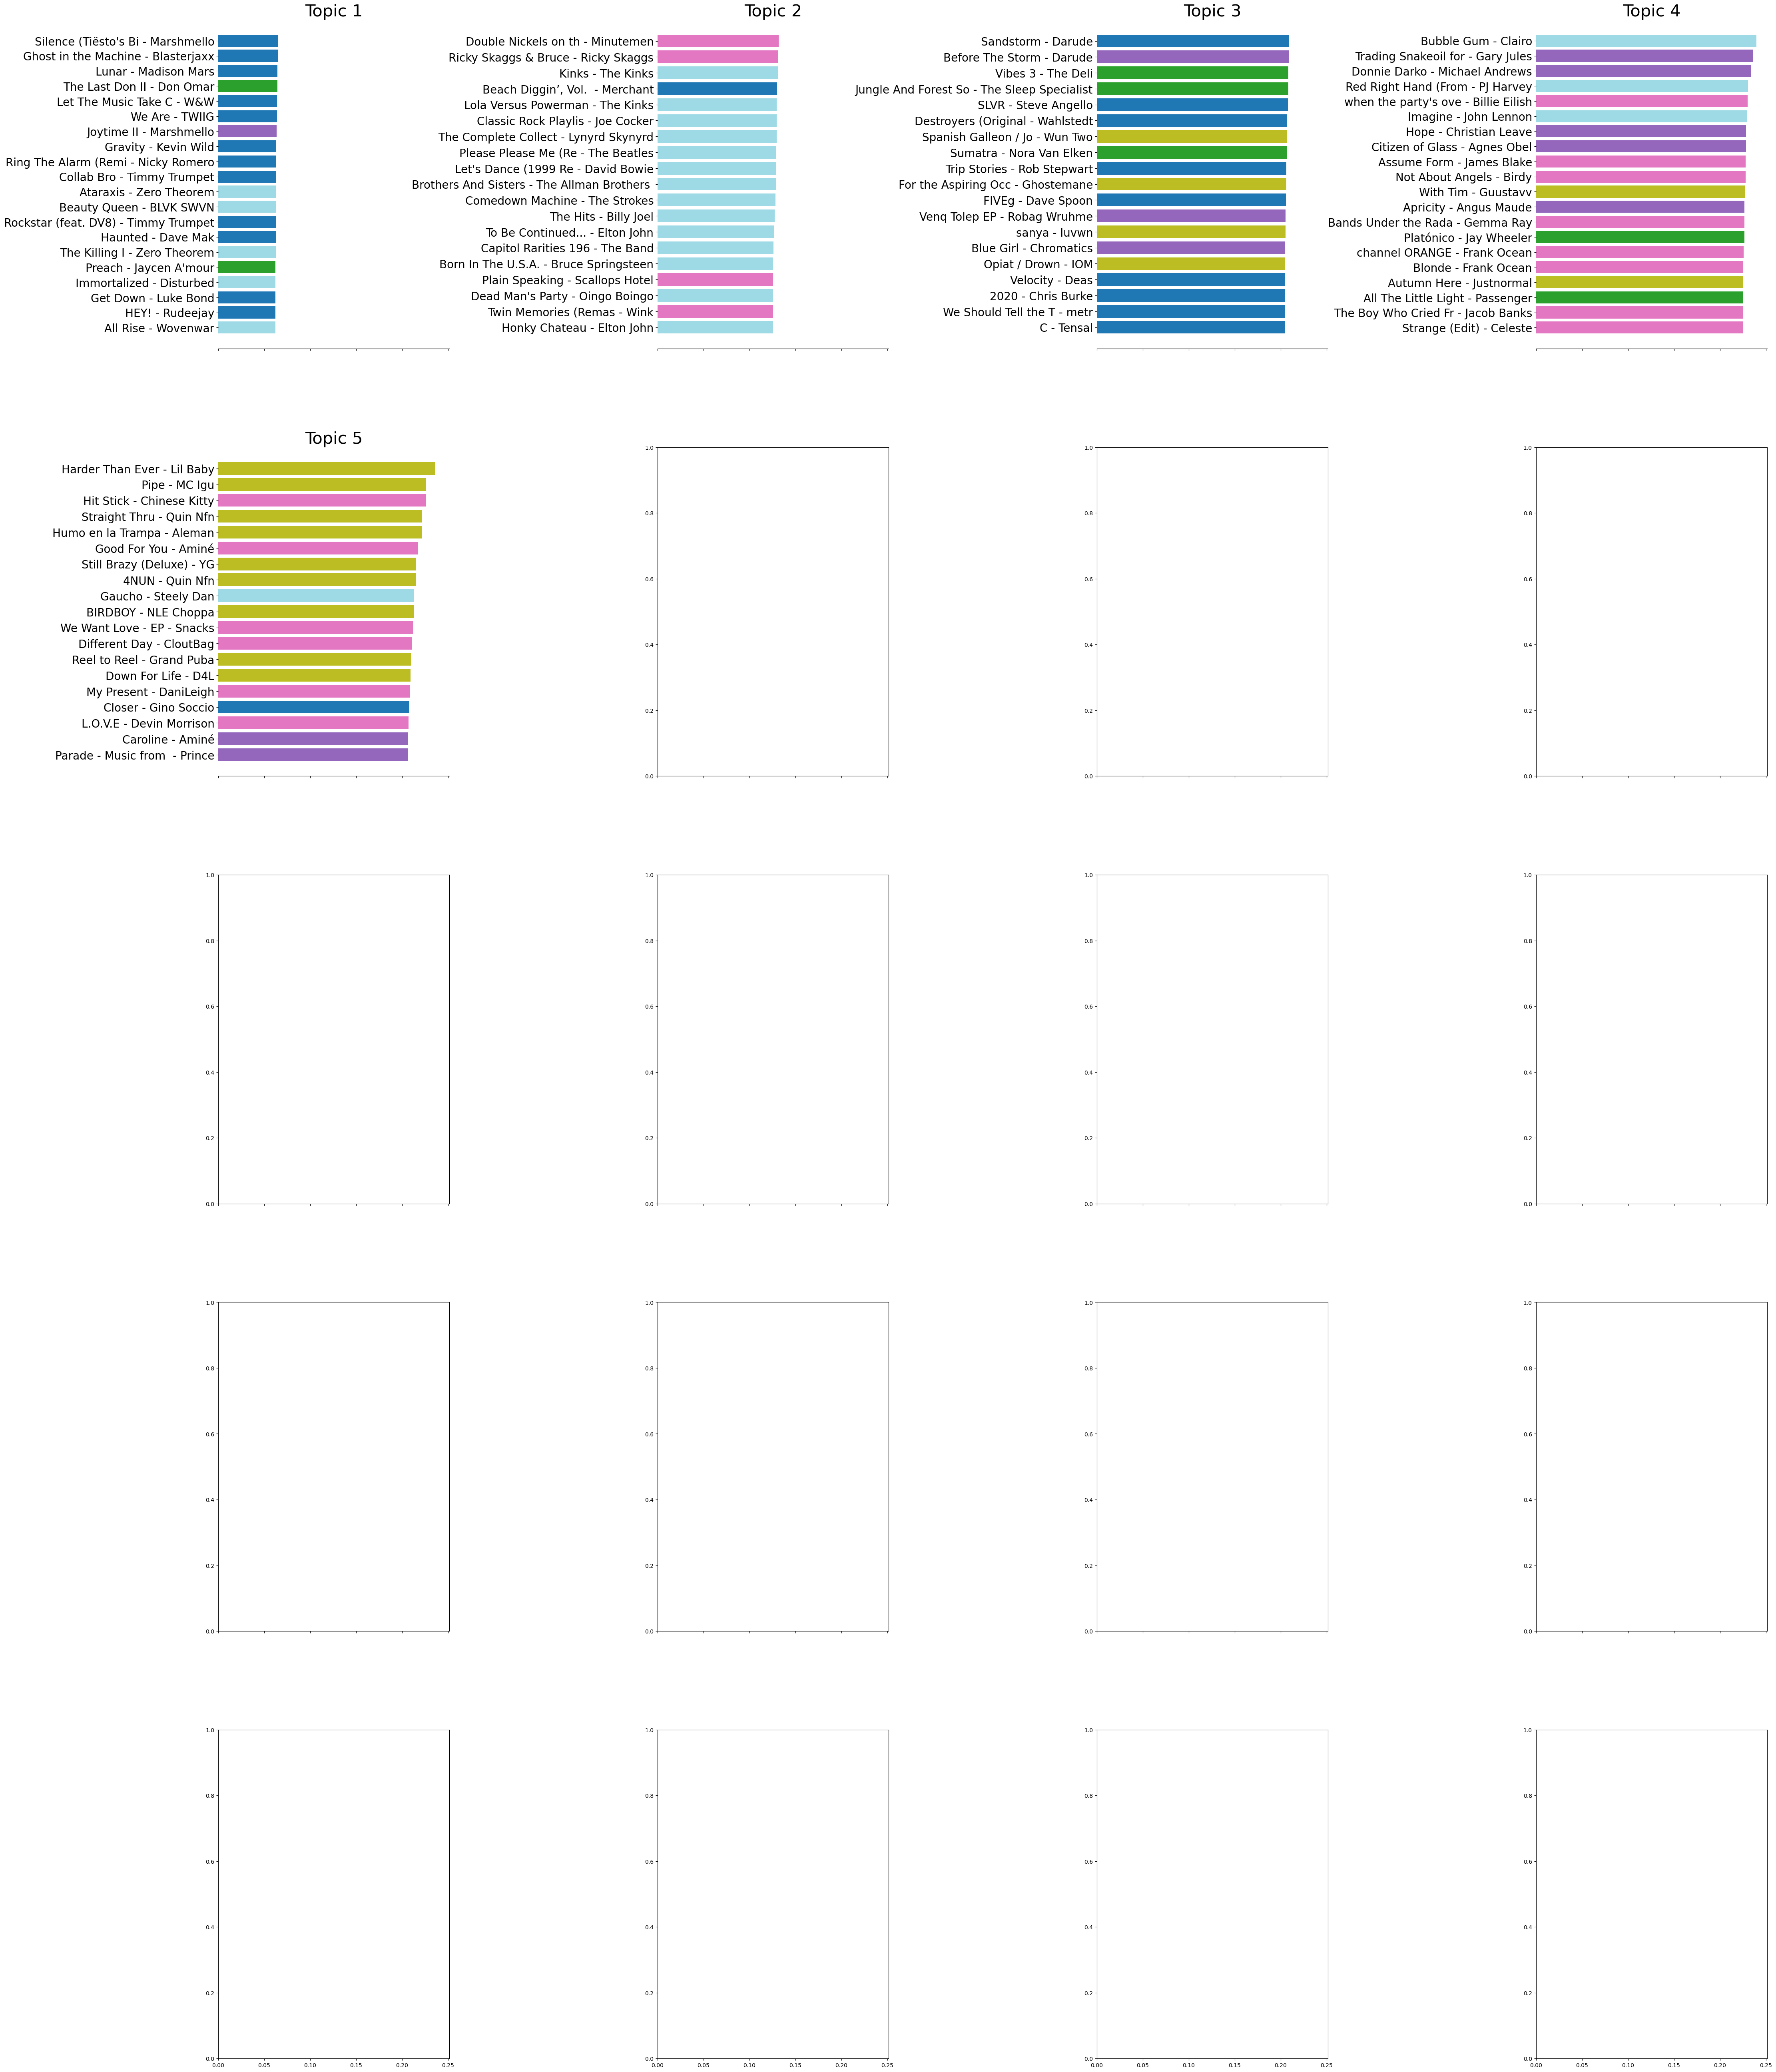

In [300]:
n_top_songs = 20
fig, axes = plt.subplots(5, 4, figsize=(50, 60), sharex=True)
axes = axes.flatten()

# Mapping genre → couleur
genre = song["playlist_genre"].values
unique_genres = np.unique(genre)
cmap = plt.get_cmap('tab20', len(unique_genres))
genre_to_color = {g: cmap(i) for i, g in enumerate(unique_genres)}

# Attribution dure : chaque musique est associée au topic où elle a la plus forte contribution
#topic_assignment = W.argmax(axis=1)

for topic_idx in range(W.shape[1]):
    ax = axes[topic_idx]
    
    # Indices des chansons associées à ce topic
    topic_song_indices = np.where(topic_assignment == topic_idx)[0]
    
    # Trie par contribution décroissante
    sorted_indices = topic_song_indices[np.argsort(W[topic_song_indices, topic_idx])[::-1]]
    
    # Top N indices
    top_indices = sorted_indices[:n_top_songs]
    
    # Labels et données
    top_labels = [
        f"{song_complete['track_album_name'].iloc[i][:20]} - {song_complete['track_artist'].iloc[i][:20]}"
        for i in top_indices
    ]
    top_scores = [W[i, topic_idx] for i in top_indices]
    top_features_genres = [genre[i] for i in top_indices]
    bar_colors = [genre_to_color[g] for g in top_features_genres]
    
    # Affichage
    ax.barh(top_labels, top_scores, color=bar_colors)
    ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="major", labelsize=20)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)

plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
plt.show()